# 🌾 Seasonal Agriculture Performance Analysis

### *Uncovering how India's farms rise and fall with the seasons*

---

**Prepared by:** Aarya Dubey

**College:** Dr. Hari Singh Gour Vishwavidyalaya

**AICTE STU ID:** STU66a50c355f54d1722092597

**Program:** VOIS for Tech — Data Analytics Internship


---

## 🎯 About This Project

Every farm tells a different story depending on *when* it's growing — a field
drenched by monsoon rains in Kharif behaves nothing like the same field
scraping by on irrigation alone during the dry heat of Zaid. This project
digs into 4,000 farm records across three cropping seasons — **Kharif, Rabi,
and Zaid** — spanning 8 states and 8 major crops, to answer one core
question:

> **How does agricultural performance actually change across seasons, and
> what patterns explain those changes?**

| | |
|---|---|
| 🌍 **Domain** | Agriculture |
| 📊 **Theme** | Seasonal Agricultural Performance |
| 🐍 **Tools** | Python · Pandas · NumPy · Matplotlib · Seaborn · SciPy |
| 📁 **Dataset** | 4,000 records · 28 features · 3 seasons · 8 states · 8 crops |

## 🧭 What This Notebook Covers

1. Data Cleaning & Preparation — handling missing values, duplicates, and outliers
2. Exploratory Data Analysis — univariate, bivariate, and multivariate visual analysis
3. Seasonal Performance Comparison — yield, revenue, cost, and profit
4. Environmental & Resource Analysis — rainfall, temperature, water usage, irrigation
5. Statistical Testing — confirming whether seasonal differences are real, not random
6. Key Insights & Recommendations — evidence-based takeaways for seasonal planning

> **📌 Scope Note:** This is a **Data Analytics** project focused on
> exploration, statistical reasoning, and visualization. No Machine Learning
> models or live dashboards are built here — the goal is to *understand the
> data deeply*, not to predict from it.

---



## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.


## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.


## 3. 📁 Dataset Overview

This project uses a farm-level agricultural dataset capturing everything
from environmental conditions to final profitability — giving a complete,
end-to-end picture of how a farm performs across a single growing season.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

| Category | Details |
|---|---|
| 📊 **Records** | 4,000 farm entries |
| 🧾 **Features** | 28 columns |
| 🌦️ **Seasons Covered** | Kharif, Rabi, Zaid |
| 🗺️ **States Covered** | 8 (e.g., Punjab, Gujarat, Tamil Nadu, Telangana...) |
| 🌾 **Crops Covered** | 8 (Wheat, Rice, Maize, Cotton, Pulses, Chilli, Groundnut, Sugarcane) |

**What the data captures, broadly grouped:**
- 🆔 **Identifiers** — Farm ID, State, District
- 🌱 **Environmental conditions** — Rainfall, Temperature, Humidity, Sunlight, Soil pH & Moisture
- 🚜 **Farming practices** — Irrigation Method, Fertilizer, Pesticide, Seed Quality
- 📈 **Production & performance** — Yield, Production, Water Efficiency, Disease/Pest Risk
- 💰 **Economics** — Market Price, Total Cost, Revenue, Profit

> **📌 Note for setup:** Place the CSV file in the same folder as this
> notebook before running the cells below — the data-loading cell assumes
> a relative path and will raise a `FileNotFoundError` otherwise.

## 4. ⚙️ Setup — Importing Required Libraries

Before diving into the data, we load the core Python libraries this
analysis depends on:

- **Pandas** — loading, cleaning, and manipulating the dataset
- **NumPy** — numerical operations and array handling
- **Matplotlib** — base plotting engine for all visualizations
- **Seaborn** — higher-level, statistically-aware charts built on top of Matplotlib

In [ ]:
# Core libraries for data handling, analysis, and visualization
import pandas as pd               # data loading & manipulation
import numpy as np                # numerical operations
import matplotlib.pyplot as plt   # base plotting
import seaborn as sns             # statistical visualizations

## 5. 📥 Loading the Dataset

We now load the dataset into a Pandas DataFrame — this is the single
object we'll clean, explore, and analyze for the rest of the notebook.

> Make sure `seasonal_agriculture_performance_dataset.csv` is placed in the
> same folder as this notebook before running the cell below.

In [ ]:
df=pd.read_csv("seasonal_agriculture_performance_dataset.csv")

## 6. 🔎 Initial Data Understanding

Before any cleaning or analysis, it's important to get a feel for the raw
dataset — its size, structure, data types, and what each column actually
represents. This step helps catch issues early (wrong data types, unexpected
categories, missing values) and builds the foundation for every analysis
step that follows.

In this section, we'll look at:
- The overall shape and structure of the dataset
- Data types of each column
- A preview of the first few records
- Summary statistics for numerical and categorical columns

### Checking the Shape of the Dataset

In [ ]:
df.shape  # Returns (number of rows, number of columns)

(4000, 28)

### Number of Rows and Columns in the Dataset

In [ ]:
print("The no of rows in the dataset :",df.shape[0])
print("The no of columns in the dataset :",df.shape[1])

The no of rows in the dataset : 4000
The no of columns in the dataset : 28


### Previewing the First Few Records

In [ ]:
df.head() # Displays the first 5 rows of the dataset by default

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### Previewing the Last Few Records

In [ ]:
df.tail() # Displays the last 5 rows of the dataset by default


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


### Statistical Summary of Numerical Columns

In [ ]:
# Generates summary statistics (count, mean, std, min, quartiles, max)
# for all numerical columns in the dataset
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


### Listing All Column Names

In [ ]:
# Displays all column names in the dataset
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [ ]:
# Displays all column names in the dataset as a Python list
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

### Checking Data Types of Each Column

In [ ]:
df.dtypes # Displays the data type of every column (e.g., int64, float64, object)

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


### Dataset Structure & Data Types

In [ ]:
# Displays column names, non-null counts, and data types for the entire dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

### Summary Statistics — Categorical Columns

In [ ]:
# Generates summary statistics for categorical (object-type) columns:
# count, number of unique values, most frequent value (top), and its frequency
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 7. 🧹 Data Quality Analysis

Before performing analysis, we investigate missing values, duplicates, data
types, and unusual/unexpected values. Data quality issues left unaddressed
can quietly distort every result that follows — from skewed averages to
misleading charts — so this step is treated as a first-class part of the
analysis, not a formality to rush through.

**Student task:** Explain what you observe and justify each cleaning decision.

### Checking for Null Values

In [ ]:
# Count of missing values per column, sorted from most to least
missing = df.isnull().sum().sort_values(ascending=False)

# Percentage of missing values per column (out of total rows), sorted the same way
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)


# Combine both into a single summary table
null_overview = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

# Keep only the columns that actually have missing values
null_overview=null_overview[null_overview["Missing_Count"] > 0]
print(null_overview)

                   Missing_Count  Missing_Percentage
Rainfall_mm                   48                 1.2
Soil_Moisture_pct             40                 1.0
Yield_Tonnes_Ha               32                 0.8


### Visualizing Missing Values

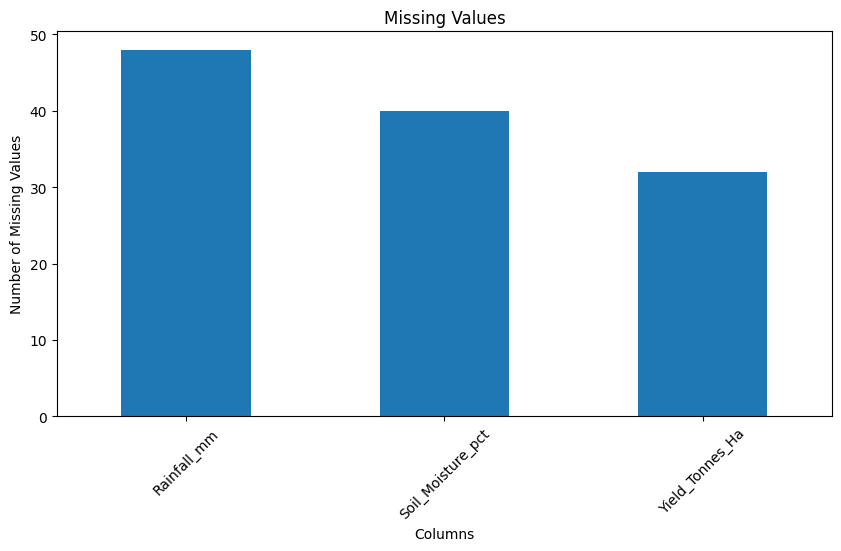

In [ ]:
# Visualize missing values

if not null_overview.empty:
    null_overview["Missing_Count"].plot(kind="bar", figsize=(10, 5))
    plt.title("Missing Values")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("No missing values found.")

### Checking for Duplicate Records

In [ ]:
# Duplicate records
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows in the dataset :", duplicate_rows)

Number of duplicate rows in the dataset : 0


### Removing Duplicate Records

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


### Re-checking Data Types After Cleaning

In [ ]:
# Confirm data types remain as expected after duplicate removal
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


### Missing Values After Duplicate Removal

In [ ]:
### Missing Values After Duplicate Removal
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


### 🧩 Missing Value Treatment

Not all missing values should be handled the same way — the right strategy
depends on the nature of each variable and what a "reasonable" placeholder
value would actually mean for that column.

**Possible approaches considered:**
- **Remove records** — only justified when missingness is extremely rare
  and unlikely to bias the dataset if dropped.
- **Fill numerical values** using an appropriate statistic (mean or median),
  chosen based on the column's distribution.
- **Fill categorical values** using the most frequent category or a
  dedicated "Unknown" label, depending on context.
- **Document the reasoning** behind each choice, rather than applying one
  rule blindly across every column.

> ⚠️ **Important:** Missing values should never be blindly replaced with
> zero — for a column like `Yield_Tonnes_Ha`, a 0 would falsely represent
> a completely failed harvest rather than a simple data gap, which would
> distort every downstream statistic and chart.

**Approach used in this notebook:**
`Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha` were all imputed
using the **median** of each column. Median was chosen over mean because
`Yield_Tonnes_Ha` is right-skewed (Sugarcane's much higher yield pulls the
mean upward), making the median a more representative "typical" value —
and the same method was applied consistently across all three columns for
simplicity and comparability.

### Identifying Categorical Columns

In [ ]:
### Identifying Categorical Columns
categorical_columns = df.select_dtypes(include="object").columns

### Previewing Unique Values in Each Categorical Column

In [ ]:
### Previewing Unique Values in Each Categorical Column
for col in categorical_columns:
    print(f"\n{col}:")
    print("Unique values:", df[col].nunique())#Shows how many different values are present in that column.
    print(df[col].dropna().unique()[:20])#Shows the first 20 unique values, ignoring missing values.


Farm_ID:
Unique values: 4000
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
Unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
Unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
Unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
Unique values: 3
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
Unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


### Listing Numerical Columns and Checking for Nulls

In [ ]:
### Listing Numerical Columns and Checking for Nulls
numerical_columns = df.select_dtypes(include="number").columns
print("Numerical columns:")
print(list(numerical_columns))

print("\nColumns with missing values:")
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        print(col, ":", df[col].isnull().sum(), "null values")

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Columns with missing values:
Rainfall_mm : 48 null values
Soil_Moisture_pct : 40 null values
Yield_Tonnes_Ha : 32 null values


### Imputing Missing Numerical Values with Median

In [ ]:
### Imputing Missing Numerical Values with Median
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### Full Statistical Summary — All Columns

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,4000.0,NaN,NaN,NaN,600.922825,287.193381,80.0,371.575,582.0,831.975,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


### Verifying No Missing Values Remain

In [ ]:
### Verifying No Missing Values Remain
df.isnull().sum().sort_values(ascending=False)

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


## 8. 🧬 Feature / Variable Review

Before analyzing seasonal performance, it helps to step back and classify
every variable in the dataset by the *role* it plays — not just its data
type. Two numerical columns (say, `Rainfall_mm` and `Revenue_INR`) can be
numerically identical in structure but conceptually worlds apart in what
they represent.

**Variable Classification:**

| Category | Variables |
|---|---|
| 🆔 **Identifier** | `Farm_ID`, `State`, `District` |
| 🏷️ **Categorical** | `Crop`, `Season`, `Irrigation_Method` |
| 🌱 **Environmental** | `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, `Soil_Moisture_pct` |
| 🚜 **Operational** | `Farm_Area_Hectares`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Seed_Quality_Score`, `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha` |
| 📈 **Production / Performance** | `Yield_Tonnes_Ha`, `Production_Tonnes`, `Water_Used_m3`, `Water_Efficiency_t_per_1000m3`, `Disease_Pest_Risk_pct` |
| 💰 **Economic** | `Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR` |

**Student task:** Explain which variables are most relevant to the
seasonal-performance problem and why.

> **Answer:** The variables most central to this analysis are `Season`
> itself (the grouping variable that drives every comparison), paired with
> the **production/performance variables** (`Yield_Tonnes_Ha`,
> `Water_Efficiency_t_per_1000m3`) and **economic variables**
> (`Profit_INR`, `Revenue_INR`, `Total_Cost_INR`) — since these directly
> answer "how well did the season perform?" The **environmental variables**
> (`Rainfall_mm`, `Avg_Temperature_C`) matter almost as much because they
> explain *why* performance shifts by season — Kharif's high rainfall, for
> instance, plausibly drives its stronger yield. **Operational variables**
> like `Irrigation_Method` and `Fertilizer_kg_ha` matter because they're
> the levers farmers can actually control, making them useful for turning
> insights into recommendations. **Identifier variables** (`Farm_ID`,
> `District`) are excluded from statistical analysis entirely — they carry
> no analytical signal and exist only to uniquely label each record.

In [ ]:
# Numerical and categorical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 9. 📊 Statistical Analysis

Before jumping into charts, the numbers themselves need to be understood.
This section computes descriptive statistics — measures of central tendency
(mean, median) and spread (standard deviation, range, IQR) — for the key
numerical variables, both overall and broken down by season.

The goal here isn't just to *display* these statistics, but to actually
**read** them: a large gap between mean and median signals skew, a high
standard deviation signals inconsistency across farms, and comparing the
same statistic across seasons is what turns a table of numbers into an
actual finding.

**What this section covers:**
- Overall summary statistics for numerical columns
- Measures of central tendency and spread (mean, median, std dev, range, IQR)
- Season-wise descriptive statistics for key performance metrics
- Written interpretation of what each result actually tells us

### Statistical Summary of Numerical Columns Only

In [ ]:
### Statistical Summary of Numerical Columns Only
stats_summary = df[numerical_columns].describe().T
stats_summary["range"] = stats_summary["max"] - stats_summary["min"]
stats_summary["IQR"] = stats_summary["75%"] - stats_summary["25%"]

stats_summary

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20,1315.200,460.40000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00,39.000,9.40000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000


### Measures of Central Tendency and Spread

In [ ]:
### Measures of Central Tendency and Spread
central_spread_summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Std_dev": df[numerical_columns].std(),
    "Min": df[numerical_columns].min(),
    "Max": df[numerical_columns].max()
})

central_spread_summary

,Mean,Median,Std_dev,Min,Max
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.507150,26.4000,6.678837,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00


### Seasonal Descriptive Summary

In [ ]:

# Seasonal descriptive summary
season_summary = df.groupby("Season")[numerical_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares                  Rainfall_mm                     \
                     mean median       std        mean median         std   
Season                                                                      
Kharif           7.944924  8.180  4.282328  849.199663  853.1  183.686045   
Rabi             7.752207  7.680  4.179402  437.615366  432.2  175.351345   
Zaid             8.091246  8.085  4.162594  304.654714  288.2  157.238490   

       Avg_Temperature_C                  Humidity_pct  ...     Profit_INR  \
                    mean median       std         mean  ...            std   
Season                                                  ...                  
Kharif         28.454019   28.5  2.510166    71.812591  ...  611549.783883   
Rabi           23.489183   23.5  2.459561    57.893178  ...  489901.254255   
Zaid           31.042088   31.0  2.554911    52.012121  ...  436356.747261   

       Water_Used_m3                      Water_Efficiency_t_per_1000m3  \
                mean  median          std                          mean   
Season                                                                    
Kharif   6102.201237  4469.0  5670.582696                      5.891834   
Rabi     5846.987093  4292.0  5397.648066                      5.186122   
Zaid     6419.893939  4805.0  5734.619854                      4.413239   

                         Disease_Pest_Risk_pct                    
        median       std                  mean median        std  
Season                                                            
Kharif  3.2770  9.833333             54.467903   54.5  10.087931  
Rabi    2.7400  8.258037             40.482114   40.6  10.104157  
Zaid    2.3015  6.930111             38.216667   37.9   9.873938  

[3 rows x 66 columns]

## 10. 📉 Univariate Analysis

Univariate analysis looks at **one variable at a time**, building a
foundational understanding of each feature's shape and spread before
combining variables together in later sections. This is the step where
we first notice things like skewness, imbalance, or unusual distributions
that later analysis needs to account for.

**This section creates and interprets plots for:**
- 🏷️ Important categorical variables (`Season`, `Crop`, `Irrigation_Method`, `State`)
- 🔢 Important numerical variables (`Rainfall_mm`, `Avg_Temperature_C`, etc.)
- 🌦️ Seasonal distribution — how balanced the dataset is across seasons
- 📈 Production/performance distributions (`Yield_Tonnes_Ha`, `Water_Efficiency_t_per_1000m3`)
- 💰 Economic distributions (`Revenue_INR`, `Total_Cost_INR`, `Profit_INR`)

> The plots below are starting points — as you explore, add or modify
> charts based on your own analytical questions and whatever patterns
> catch your attention along the way.

### Univariate: Season Distribution

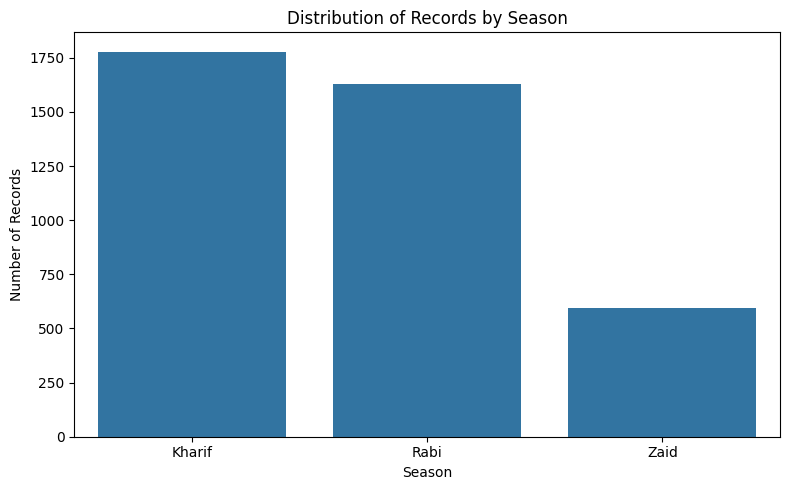

In [ ]:
### Univariate: Season Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Univariate: Crop Distribution

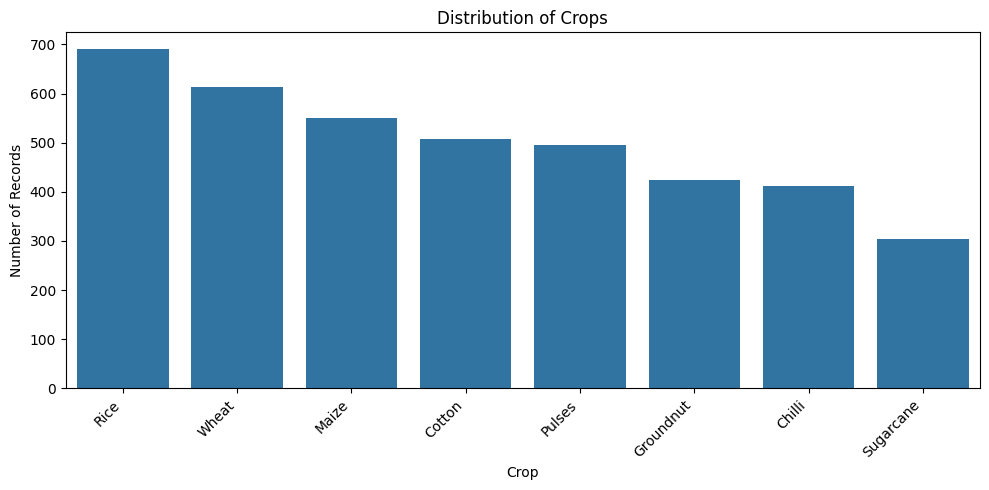

In [ ]:
### Univariate: Crop Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

# Univariate: Profit distribution

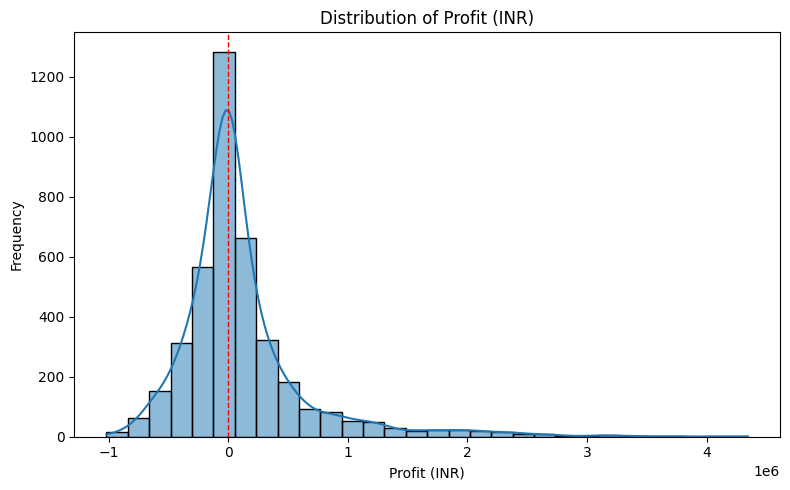

In [ ]:
# Univariate: Profit distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Profit_INR"], kde=True, bins=30)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Distribution of Profit (INR)")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Univariate: Rainfall distribution

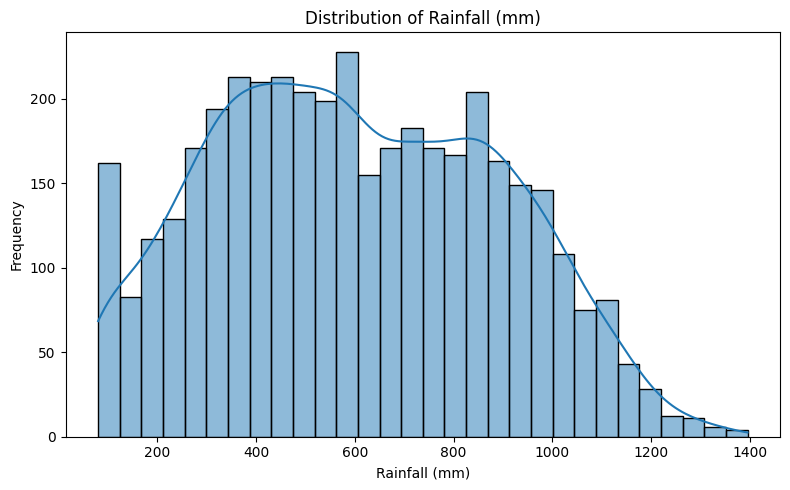

In [ ]:
# Univariate: Rainfall distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Rainfall_mm"], kde=True, bins=30)
plt.title("Distribution of Rainfall (mm)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Univariate: Yield Distribution

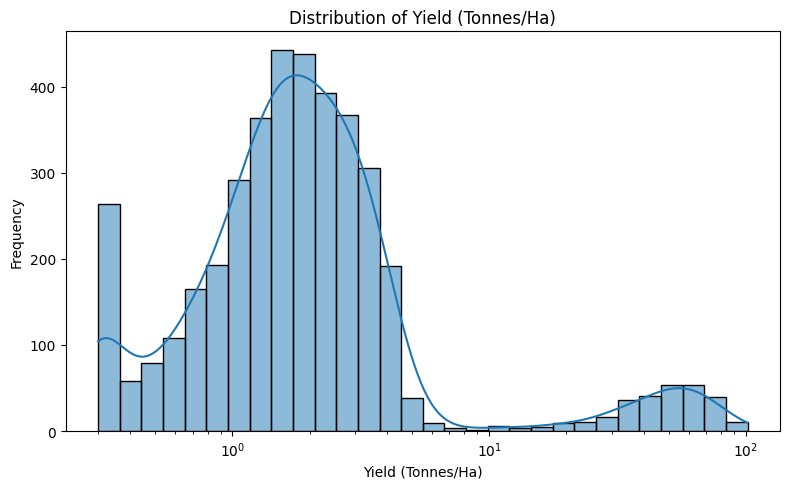

In [ ]:
# Univariate: Yield distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Yield_Tonnes_Ha"], kde=True, bins=30,log_scale=True)
plt.title("Distribution of Yield (Tonnes/Ha)")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Detecting Outliers in Yield

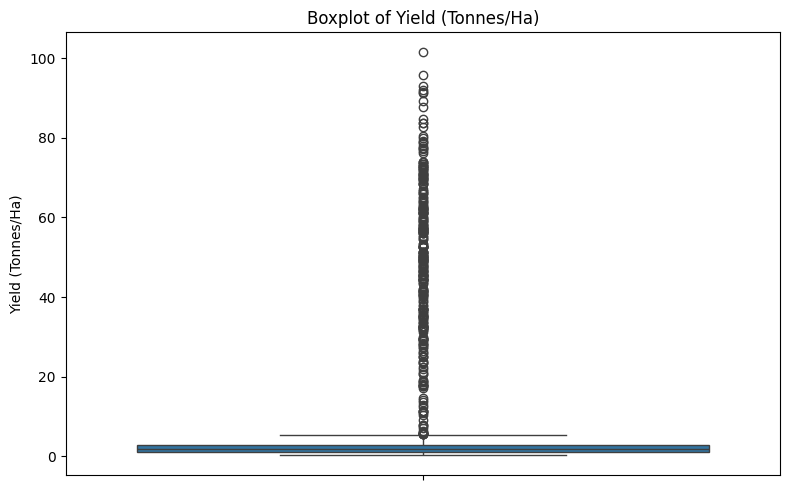

In [ ]:
### Detecting Outliers in Yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Boxplot of Yield (Tonnes/Ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

## 11. 🎯 Outlier Analysis

Extreme values aren't automatically "wrong" — they can just as easily be
genuine, meaningful data points. This section investigates potential
outliers using both statistical (IQR-based) and visual (boxplot) methods,
across the dataset's key numerical variables.

**Student task:** Do not automatically delete outliers. For each extreme
value flagged, decide whether it's:
- 🚫 **A data-entry problem** — an implausible or impossible value (e.g.,
  negative rainfall, a yield of 10,000 t/ha)
- ✅ **A legitimate observation** — a real, explainable value that simply
  differs from the rest (e.g., Sugarcane's naturally higher yield)
- 🔍 **Something requiring further investigation** — plausible but unusual
  enough to warrant a closer look before deciding either way

> The goal of this section is judgment, not deletion — outliers are
> investigated and explained, not blindly removed.

### Univariate: Season Distribution (Pie Chart)

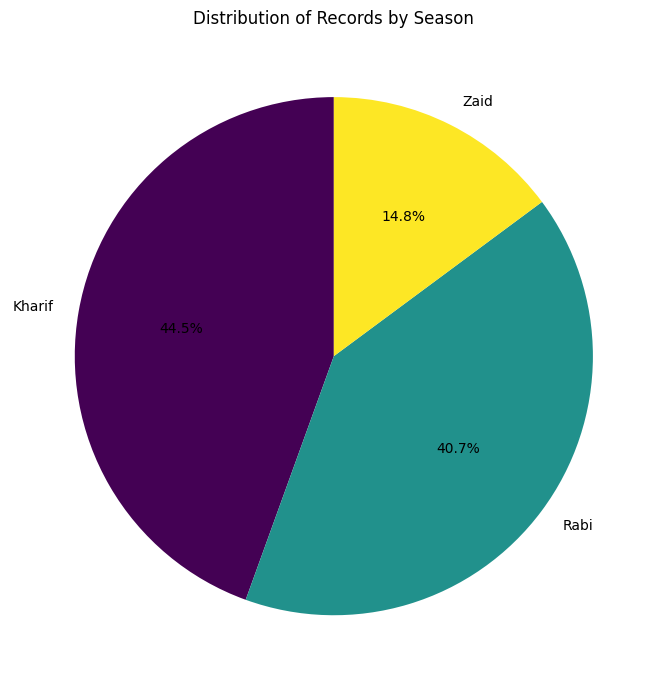

In [ ]:
### Univariate: Season Distribution (Pie Chart)
plt.figure(figsize=(7, 7))
df["Season"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, cmap="viridis")
plt.title("Distribution of Records by Season")
plt.ylabel("")  # hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

### Detecting Outliers Across All Numerical Columns (IQR Method)

In [ ]:
### Detecting Outliers Across All Numerical Columns (IQR Method)
outlier_report = []

for col in numerical_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_report.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_report = pd.DataFrame(outlier_report).sort_values("Outlier_Count", ascending=False)
outlier_report

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.000000,7.635670e+05,404,10.10
14,Production_Tonnes,-23.982500,5.335750e+01,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.572875,1.038412e+01,322,8.05
13,Yield_Tonnes_Ha,-1.620000,5.500000e+00,302,7.55
19,Water_Used_m3,-6072.750000,1.617125e+04,276,6.90
17,Revenue_INR,-736519.000000,1.780911e+06,240,6.00
9,Potassium_kg_ha,30.100000,1.797000e+02,32,0.80
4,Sunlight_Hours_Day,4.350000,1.035000e+01,26,0.65
8,Phosphorus_kg_ha,11.400000,1.042000e+02,16,0.40
10,Fertilizer_kg_ha,19.137500,3.520375e+02,15,0.38


## 12. 🔗 Bivariate Analysis

Bivariate analysis moves beyond looking at variables in isolation and
instead examines the relationship or difference **between two variables**
at a time. This is where the seasonal-performance question really starts
to take shape — comparing outcomes like yield, profit, and water usage
directly against `Season` (and other key variables) to see whether real
differences exist.

**This section investigates relationships such as:**
- 🌾 `Season` vs `Yield_Tonnes_Ha` — does yield actually change by season?
- 💰 `Season` vs `Profit_INR` — which season is most/least profitable?
- 💧 `Season` vs `Water_Used_m3` — does water usage shift across seasons?
- 🌧️ `Rainfall_mm` vs `Yield_Tonnes_Ha` — does more rainfall mean more yield?
- 🚜 `Irrigation_Method` vs `Yield_Tonnes_Ha` — which method performs best?

> Each plot here is chosen to answer a specific, relevant question about
> seasonal agricultural performance — not just to show a relationship for
> its own sake.

# Bivariate: Season vs Yield

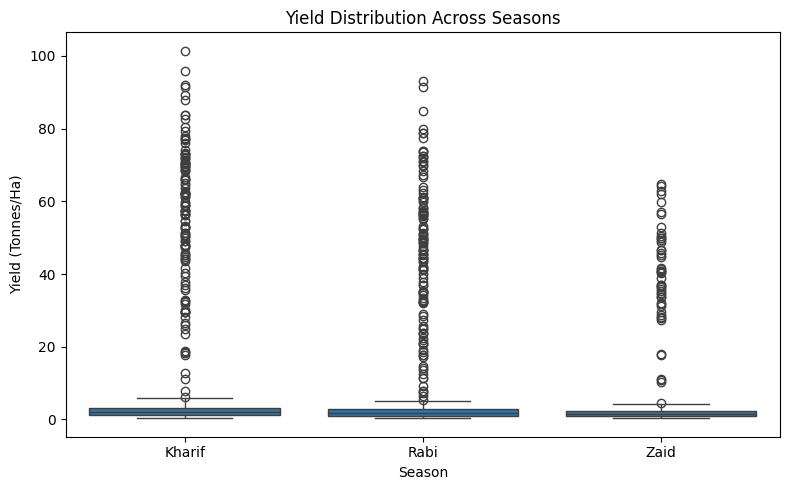

In [ ]:
# Bivariate: Season vs Yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

# Bivariate: Season vs Profit

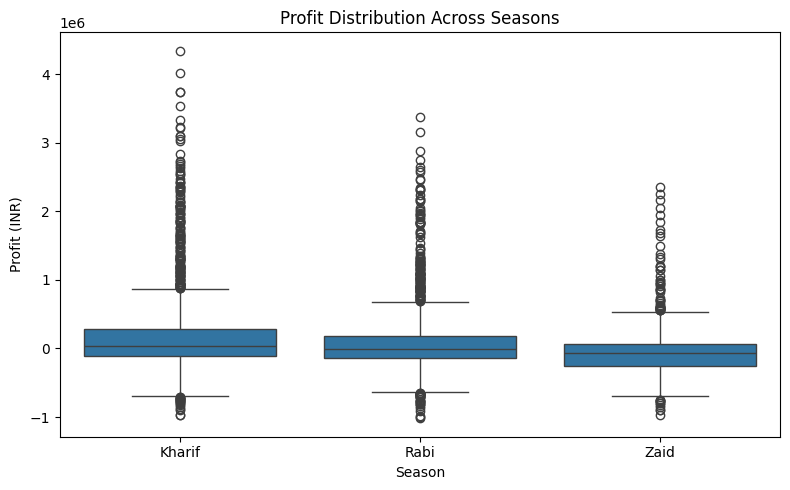

In [ ]:
# Bivariate: Season vs Profit
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

### 📊 Bar Plots for Bivariate Analysis

Bar plots are used here to compare **average values** of key performance
metrics across categories like `Season` and `Irrigation_Method` — useful
for quickly spotting which group leads or lags, before diving into the
fuller distribution view with boxplots.

### Average Yield Across Seasons (Bar Plot)

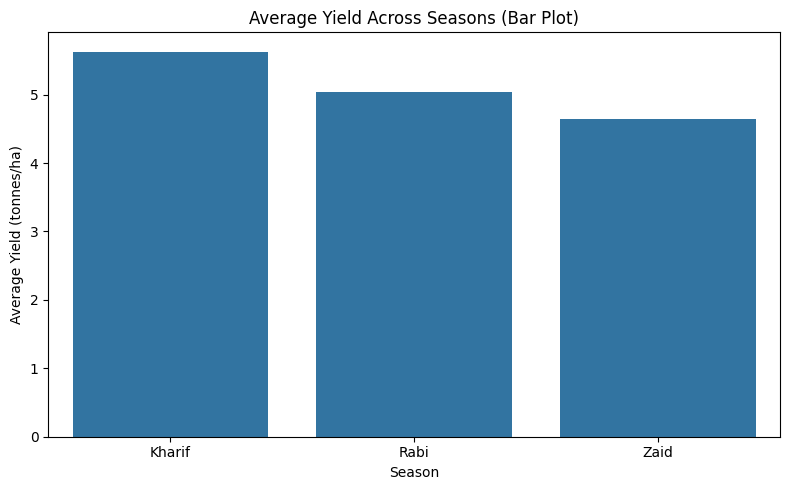

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### Bivariate: Season vs Average Profit (Bar Plot)

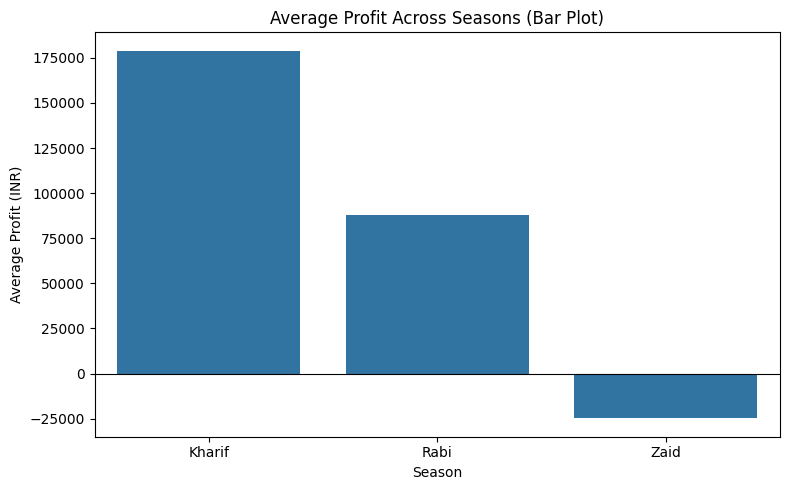

In [ ]:
### Bivariate: Season vs Average Profit (Bar Plot)
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

# Bivariate: Season vs Water Usage

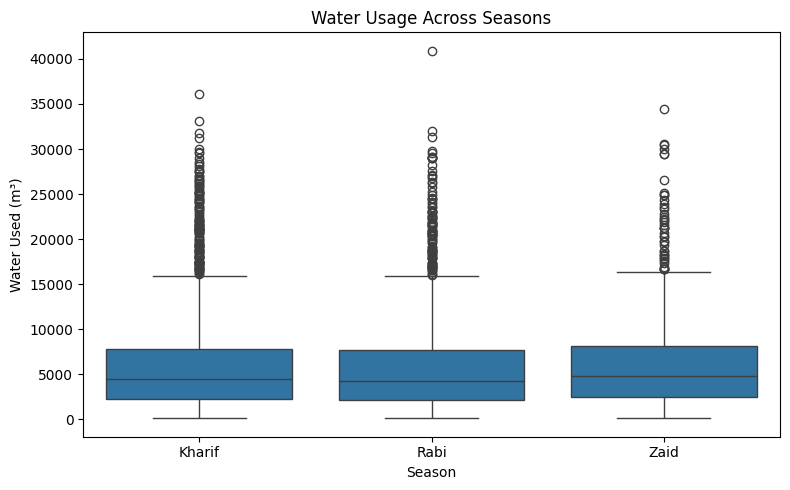

In [ ]:
# Bivariate: Season vs Water Usage
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()

### Bivariate: Season vs Average Water Usage (Bar Plot)

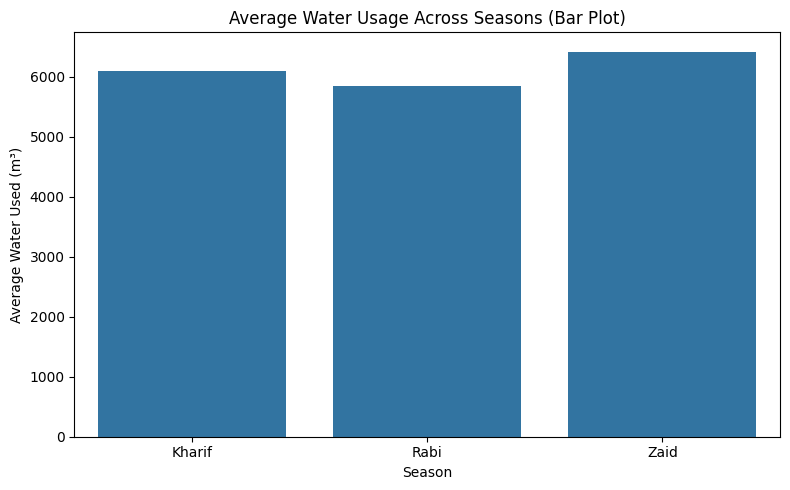

In [ ]:
### Bivariate: Season vs Average Water Usage (Bar Plot)
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None)
plt.title("Average Water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

# Bivariate: Rainfall vs Yield

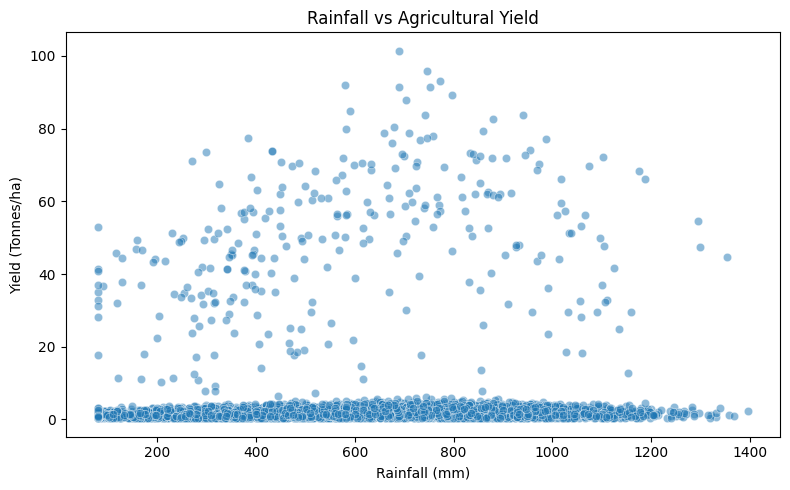

In [ ]:
# Bivariate: Rainfall vs Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

# Bivariate: Farm Area vs Production

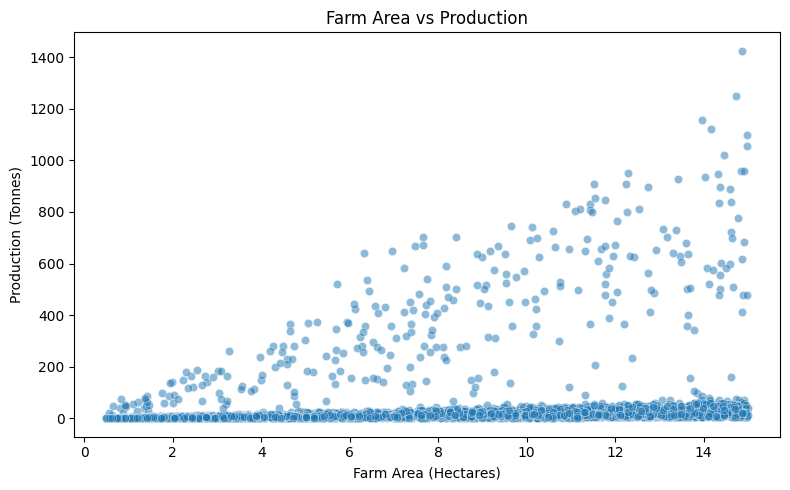

In [ ]:
# Bivariate: Farm Area vs Production
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()

### Bivariate: Irrigation Method vs Average Yield (Bar Plot)

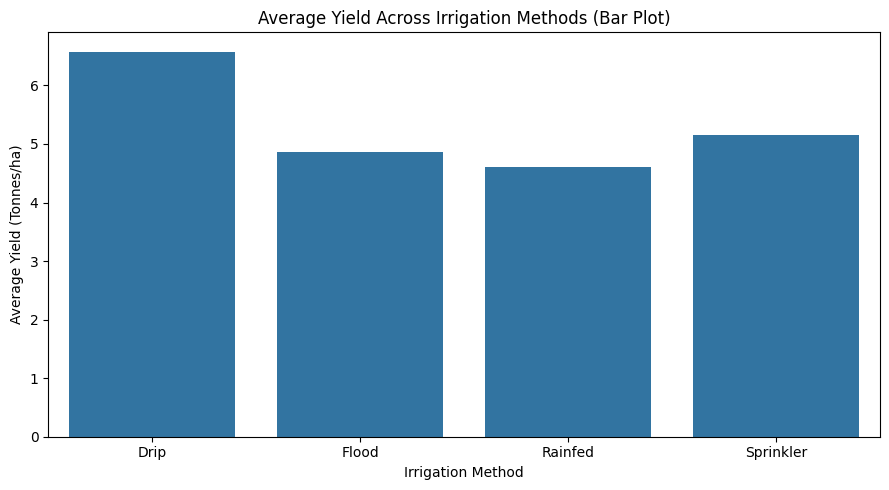

In [ ]:
### Bivariate: Irrigation Method vs Average Yield (Bar Plot)
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

### Bivariate: Irrigation Method by Season

In [ ]:
### Bivariate: Irrigation Method by Season
irrigation_season_counts = pd.crosstab(df["Season"], df["Irrigation_Method"])
irrigation_season_counts


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


### Bivariate: Irrigation Method Mix by Season (Stacked Bar, %)

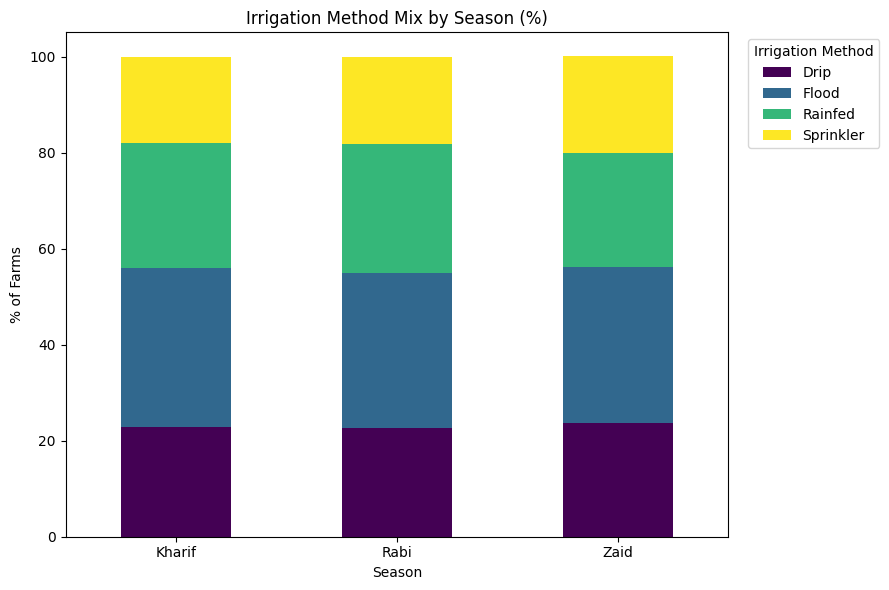

In [ ]:
### Irrigation Method Mix by Season (Stacked Bar, %)
irrigation_season_pct = pd.crosstab(df["Season"], df["Irrigation_Method"], normalize="index") * 100
irrigation_season_pct = irrigation_season_pct.round(1)

irrigation_season_pct.plot(kind="bar", stacked=True, figsize=(9, 6), colormap="viridis")
plt.title("Irrigation Method Mix by Season (%)")
plt.xlabel("Season")
plt.ylabel("% of Farms")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Bivariate: Seasonal Environmental Conditions

**Key question:** How do environmental conditions (rainfall, temperature,
humidity, sunlight, soil properties) differ across seasons?

In [ ]:
## Seasonal Environmental Conditions

# **Key question:** How do environmental conditions (rainfall, temperature, humidity, sunlight, soil properties) differ across seasons?
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
            'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']
env_summary = df.groupby('Season', observed=True)[env_cols].mean().round(2)
env_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,849.20,28.45,71.81,6.79,6.73,31.15
Rabi,437.62,23.49,57.89,7.59,6.67,24.07
Zaid,304.65,31.04,52.01,8.18,6.69,19.28


### Bivariate: Visualizing Seasonal Environmental Conditions

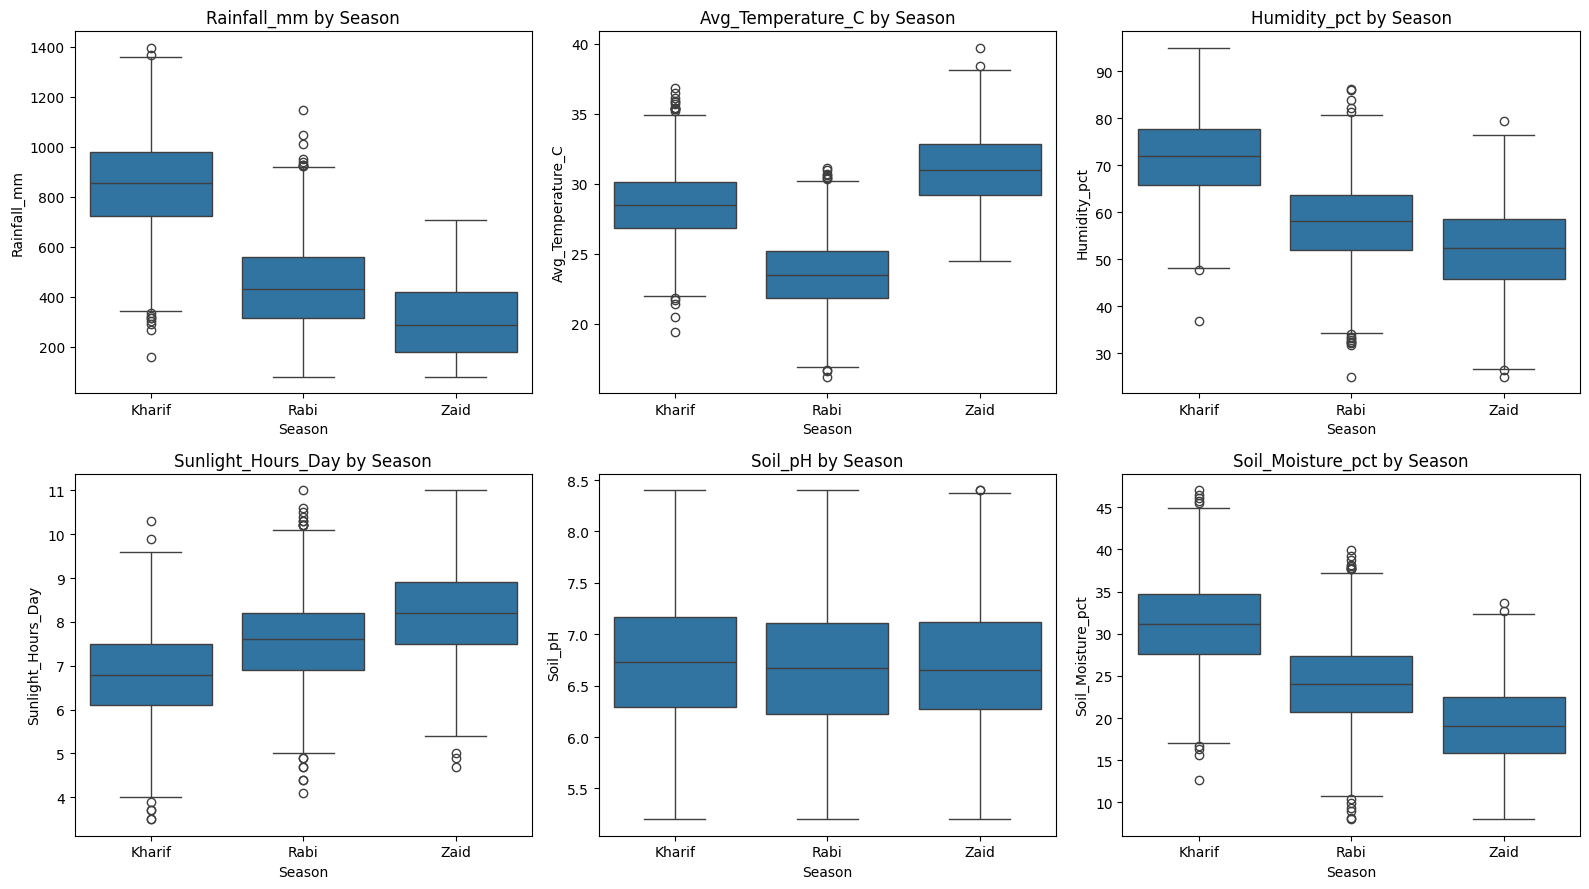

In [ ]:
### Visualizing Seasonal Environmental Conditions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, env_cols):
    sns.boxplot(data=df, x="Season", y=col, ax=ax)
    ax.set_title(f"{col} by Season")
    ax.set_xlabel("Season")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## 13. 🕸️ Multivariate Analysis

Multivariate analysis goes a step further than bivariate comparisons by
examining **three or more variables together** — this is where genuinely
interesting, non-obvious patterns tend to surface, since real-world
agricultural performance is rarely explained by a single factor in
isolation.

**This section investigates how `Season` interacts with:**
- 🌾 **Crop** — does the seasonal yield pattern hold consistently across
  every crop, or does it vary?
- 🗺️ **Region/State** — is the seasonal effect nationwide, or concentrated
  in specific states?
- 🌦️ **Environmental conditions** — how do rainfall, temperature, and
  humidity jointly relate to yield within each season?
- 🚜 **Resource usage** — does irrigation method effectiveness change
  depending on the season?
- 💰 **Economic performance** — do profit patterns shift differently than
  yield patterns when a third variable is introduced?

> Combining three or more variables in a single plot (via color, size, or
> faceting) makes it possible to catch interactions that two-variable
> comparisons alone would miss.

### Multivariate: Effect of Environmental Conditions on Yield Across Seasons

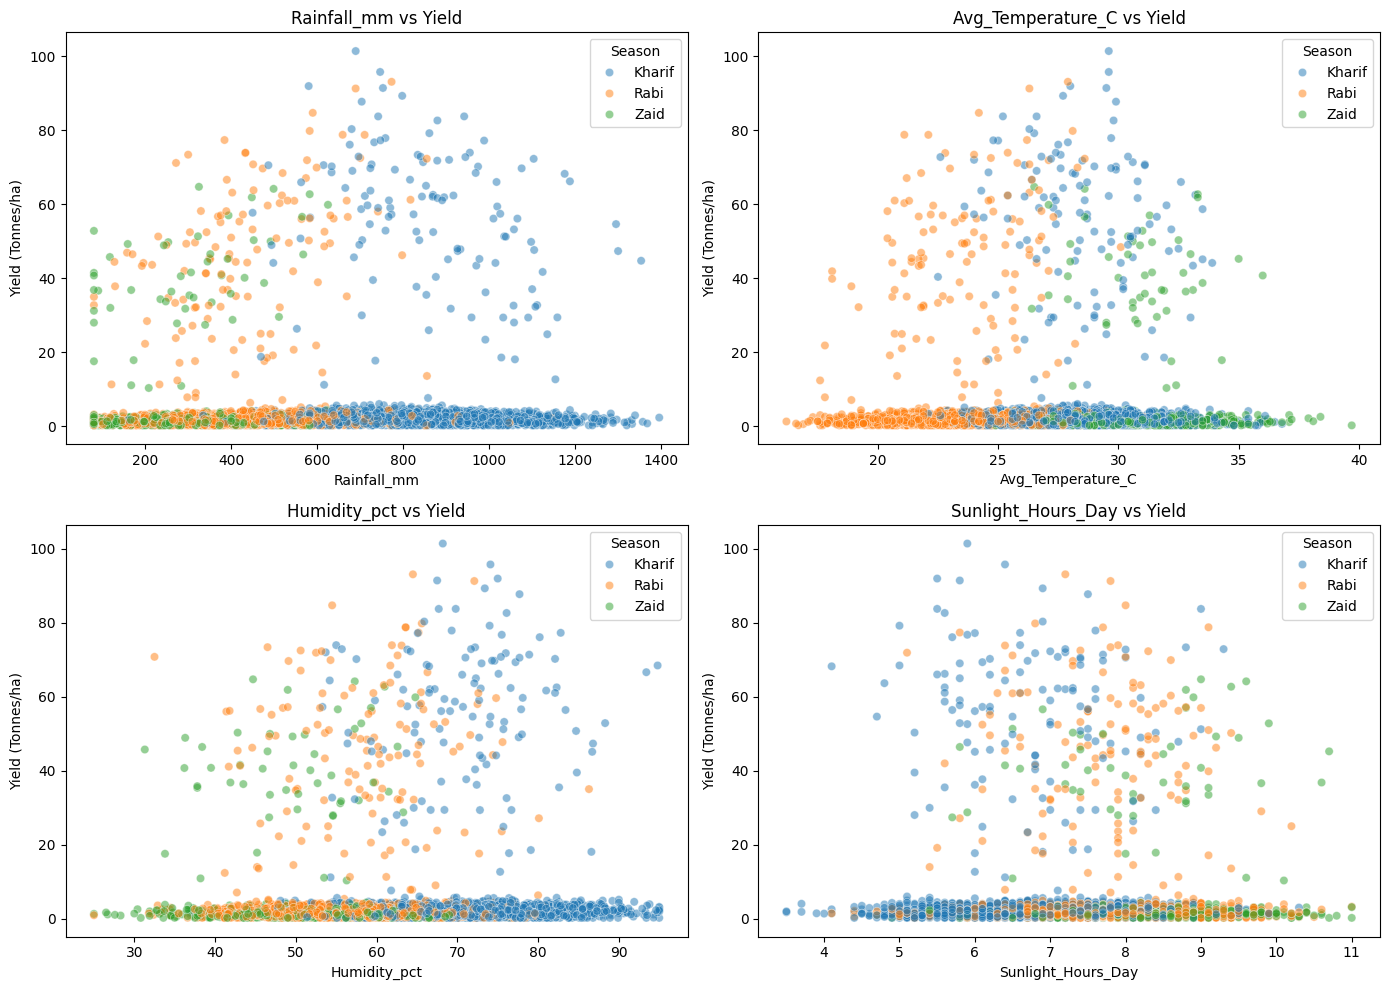

In [ ]:
### Effect of Environmental Conditions on Yield Across Seasons
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, env_cols):
    sns.scatterplot(data=df, x=col, y="Yield_Tonnes_Ha", hue="Season", alpha=0.5, ax=ax)
    ax.set_title(f"{col} vs Yield")
    ax.set_xlabel(col)
    ax.set_ylabel("Yield (Tonnes/ha)")

plt.tight_layout()
plt.show()

# Multivariate: Season, crop and yield

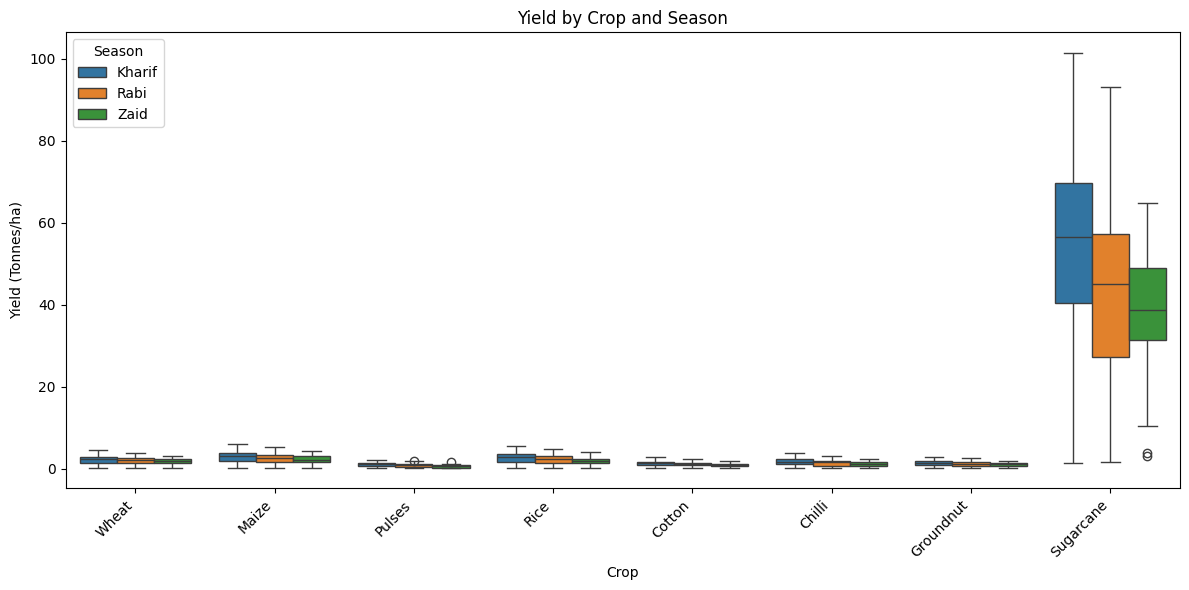

In [ ]:
# Multivariate: Season, crop and yield
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.legend(title="Season")
plt.tight_layout()
plt.show()

# Build the crop-season summary used for the grouped bar plot

In [ ]:
# Build the crop-season summary used for the grouped bar plot
crop_season_summary = df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"].mean().reset_index()
crop_season_summary.rename(columns={"Yield_Tonnes_Ha": "Average_Yield"}, inplace=True)

### Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

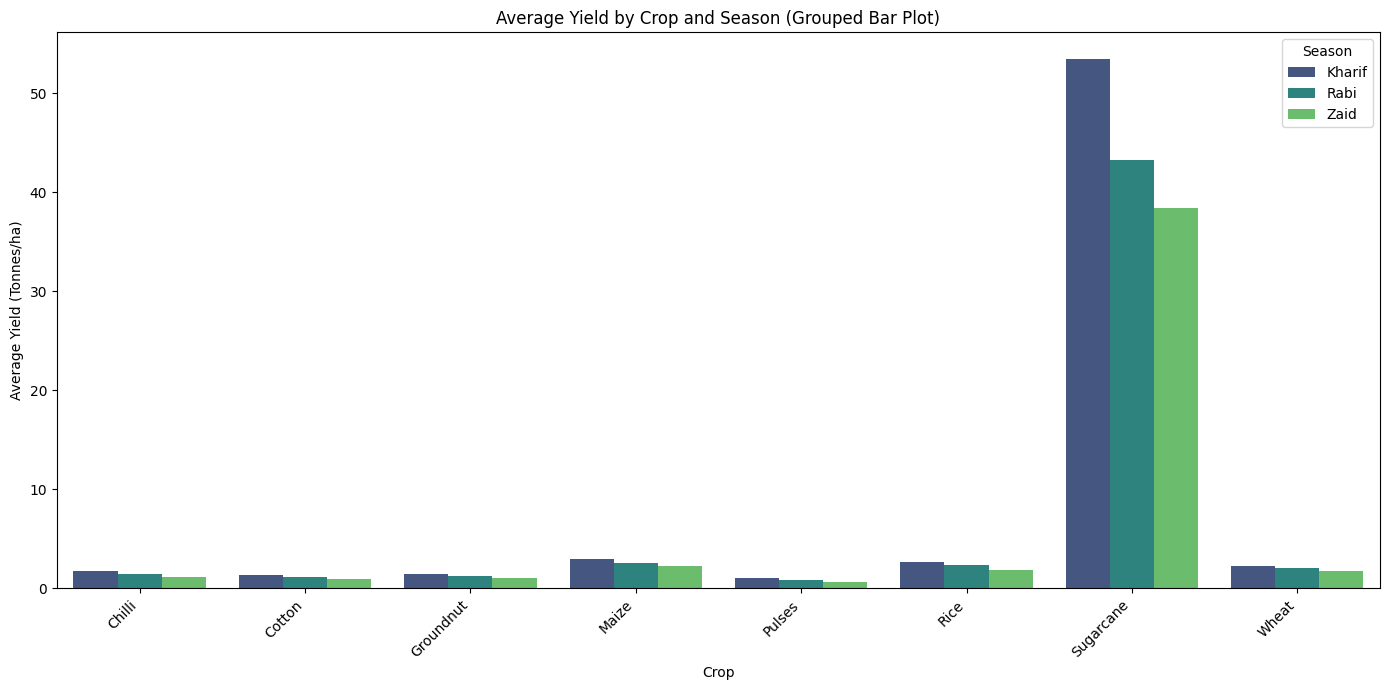

In [ ]:
### Multivariate: Grouped Bar Plot of Average Yield by Crop and Season
plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_summary.reset_index(), x="Crop", y="Average_Yield", hue="Season", palette="viridis")
plt.title("Average Yield by Crop and Season (Grouped Bar Plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/ha)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

### Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

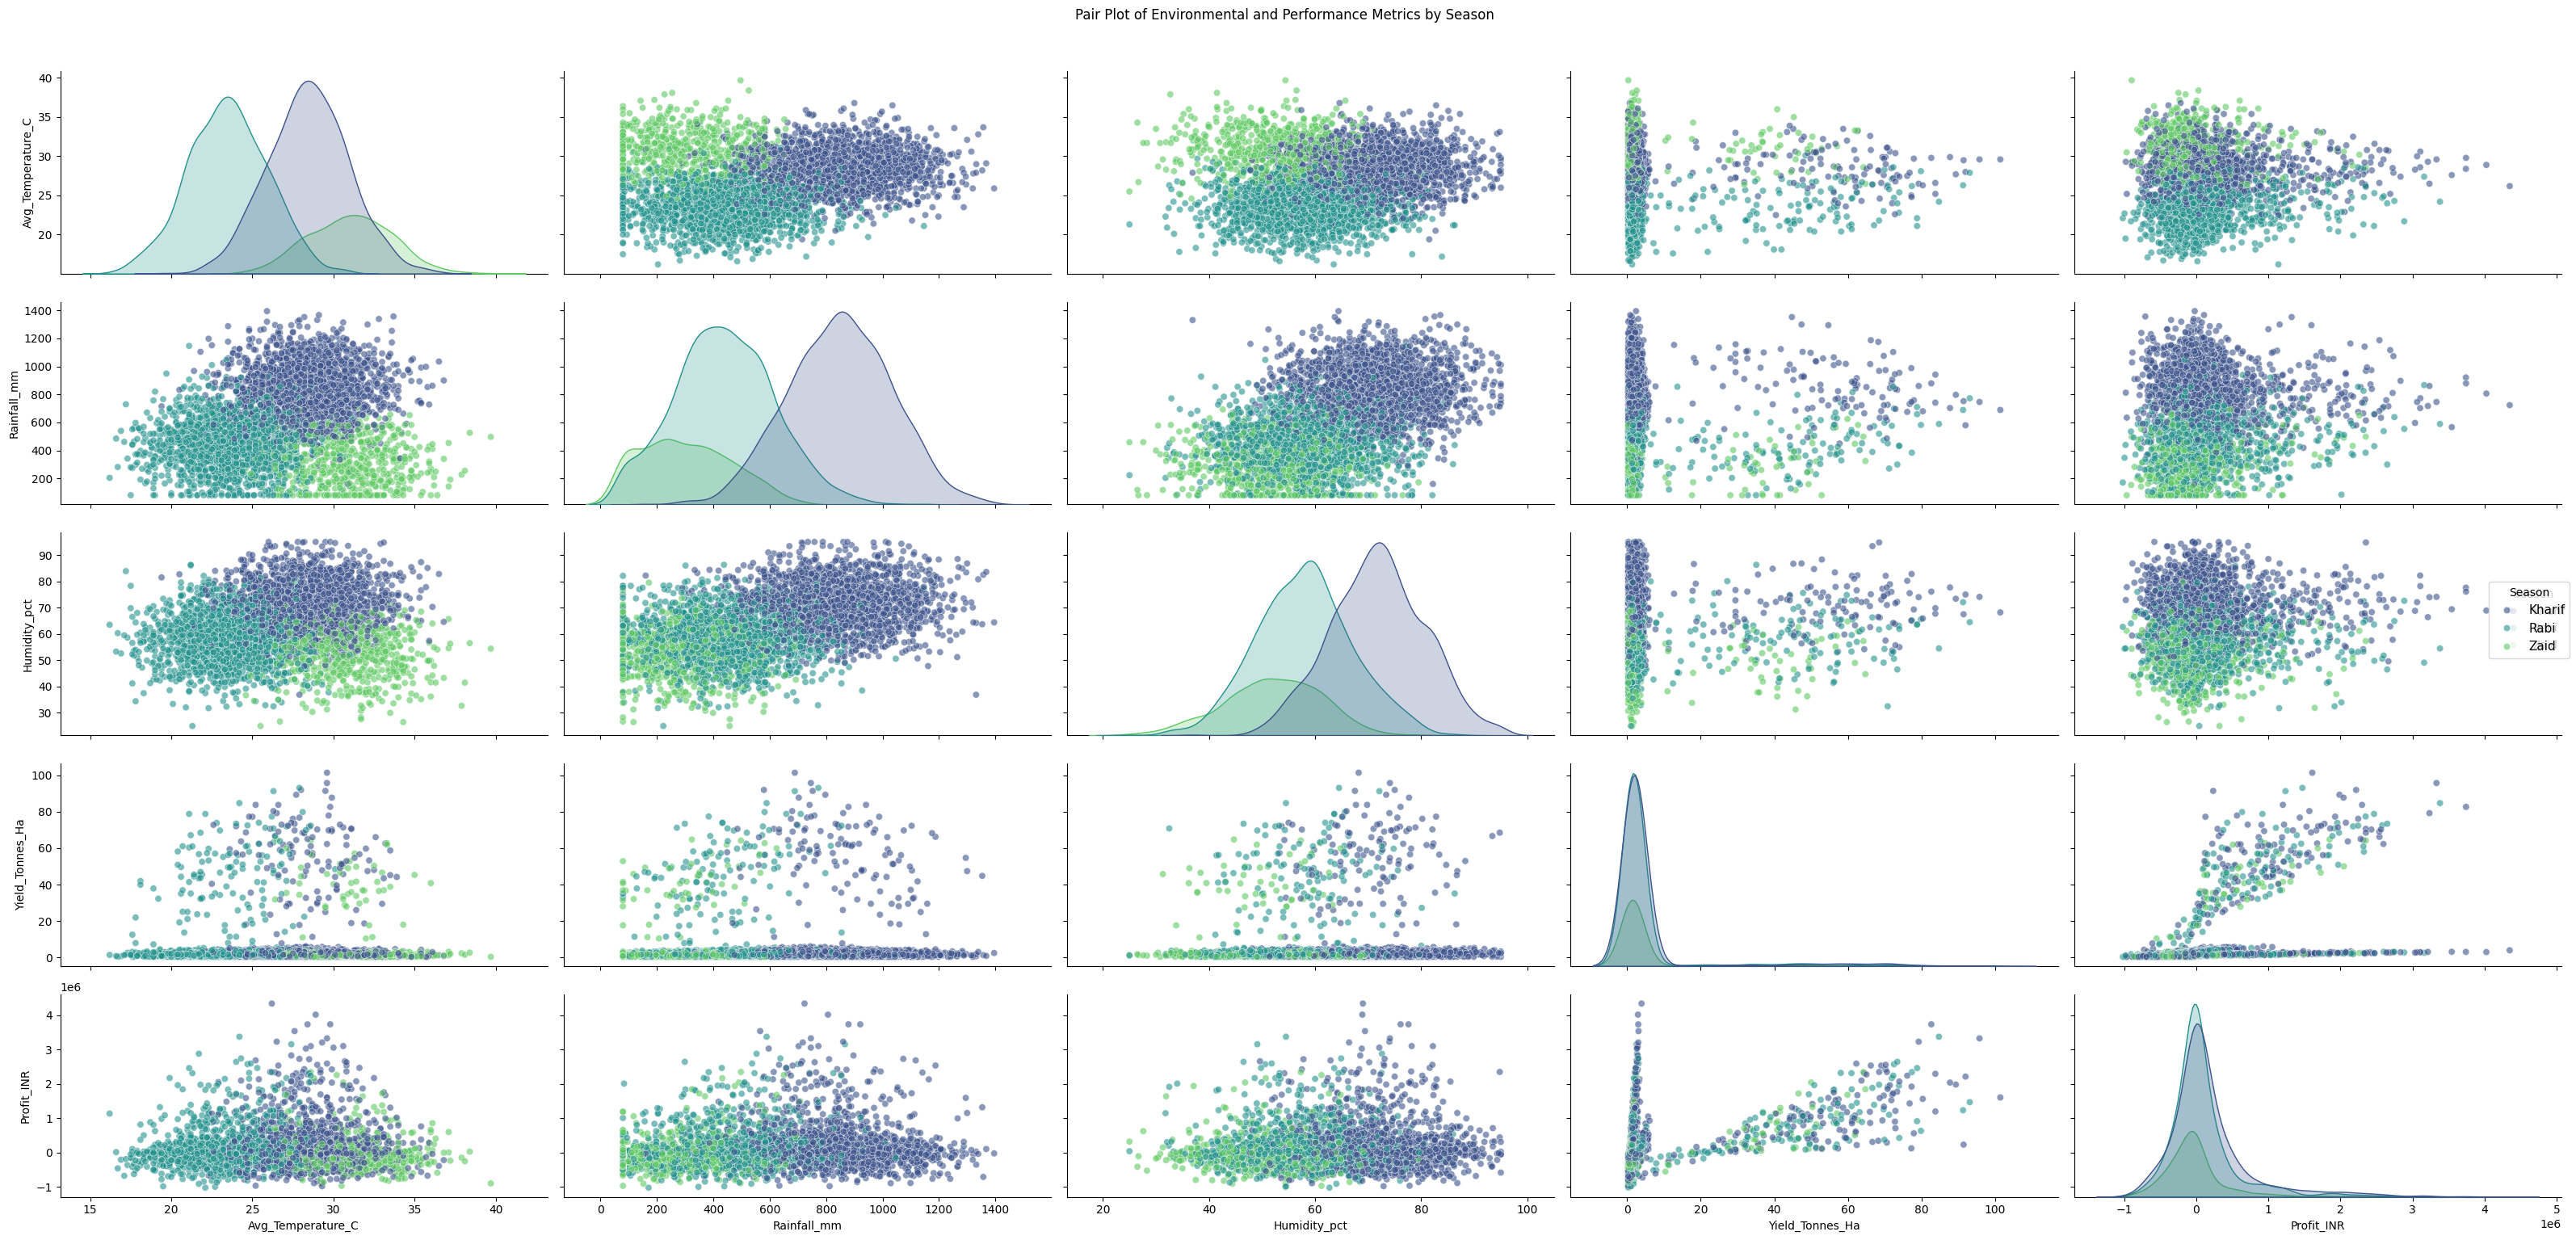

In [ ]:
### Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season
selected_columns = ["Avg_Temperature_C", "Rainfall_mm", "Humidity_pct", "Yield_Tonnes_Ha", "Profit_INR", "Season"]

g = sns.pairplot( df[selected_columns], hue="Season", palette="viridis", height=3,  aspect=2, plot_kws={"alpha": 0.6} )
plt.suptitle("Pair Plot of Environmental and Performance Metrics by Season", y=1.02)  # Adjust subtitle position
g.add_legend( title="Season", fontsize=11, title_fontsize=12, frameon=True )
plt.tight_layout()
plt.show()

### Multivariate: Heatmap of Average Yield by State and Season

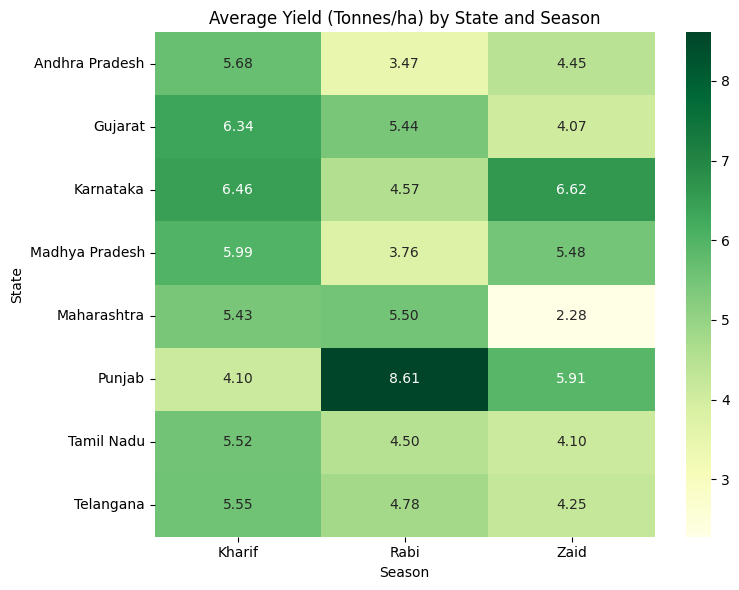

In [ ]:
### Heatmap: Average Yield by State and Season
state_season_pivot = df.pivot_table(index="State", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean").round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(state_season_pivot, annot=True, fmt=".2f", cmap="YlGn")
plt.title("Average Yield (Tonnes/ha) by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Multivariate: Season, Irrigation and Yield

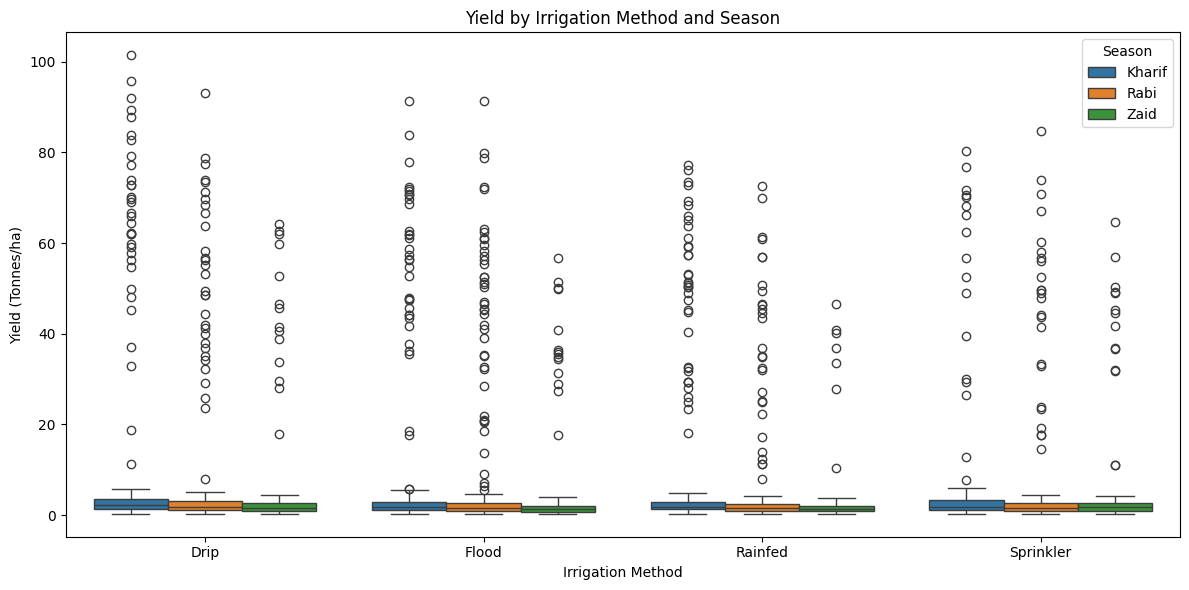

In [ ]:
### Multivariate: Season, Irrigation and Yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

### Multivariate: State, Irrigation Method and Crop — Distribution Overview

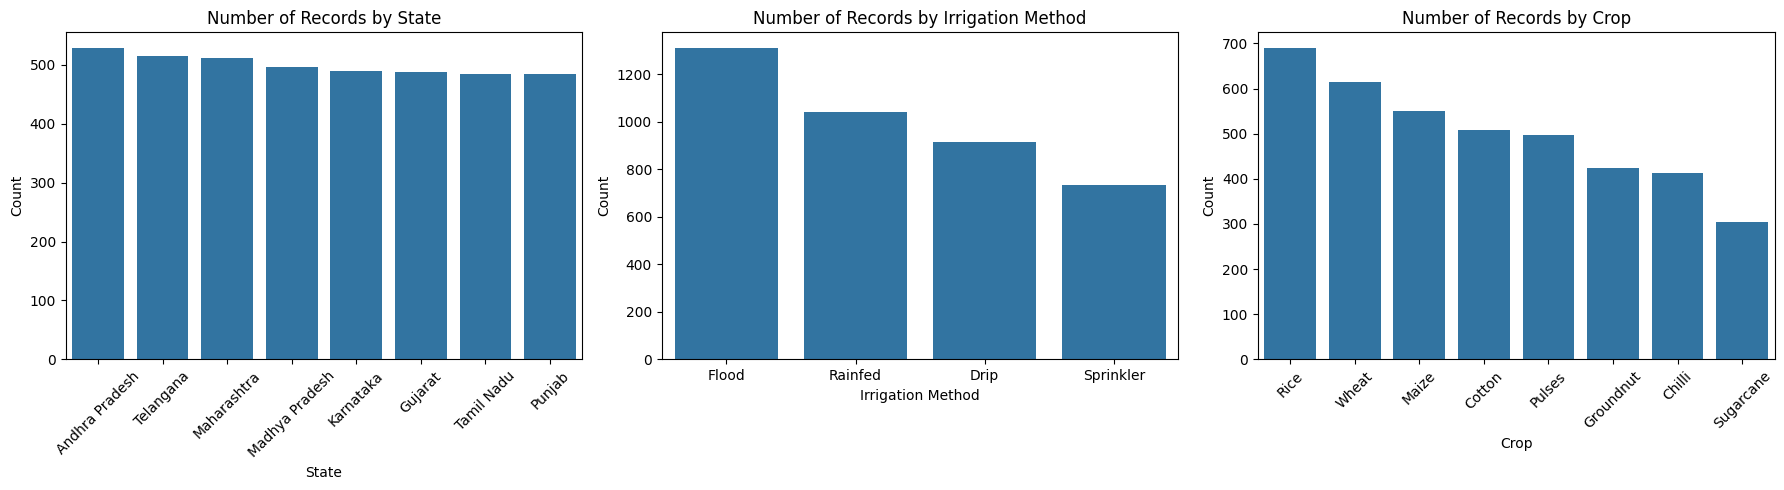

In [ ]:
### State, Irrigation Method and Crop — Distribution Overview
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="State", order=df["State"].value_counts().index, ax=axes[0])
axes[0].set_title("Number of Records by State")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="Irrigation_Method", order=df["Irrigation_Method"].value_counts().index, ax=axes[1])
axes[1].set_title("Number of Records by Irrigation Method")
axes[1].set_xlabel("Irrigation Method")
axes[1].set_ylabel("Count")

sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, ax=axes[2])
axes[2].set_title("Number of Records by Crop")
axes[2].set_xlabel("Crop")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Multivariate: Yield by State, Crop and Irrigation Method

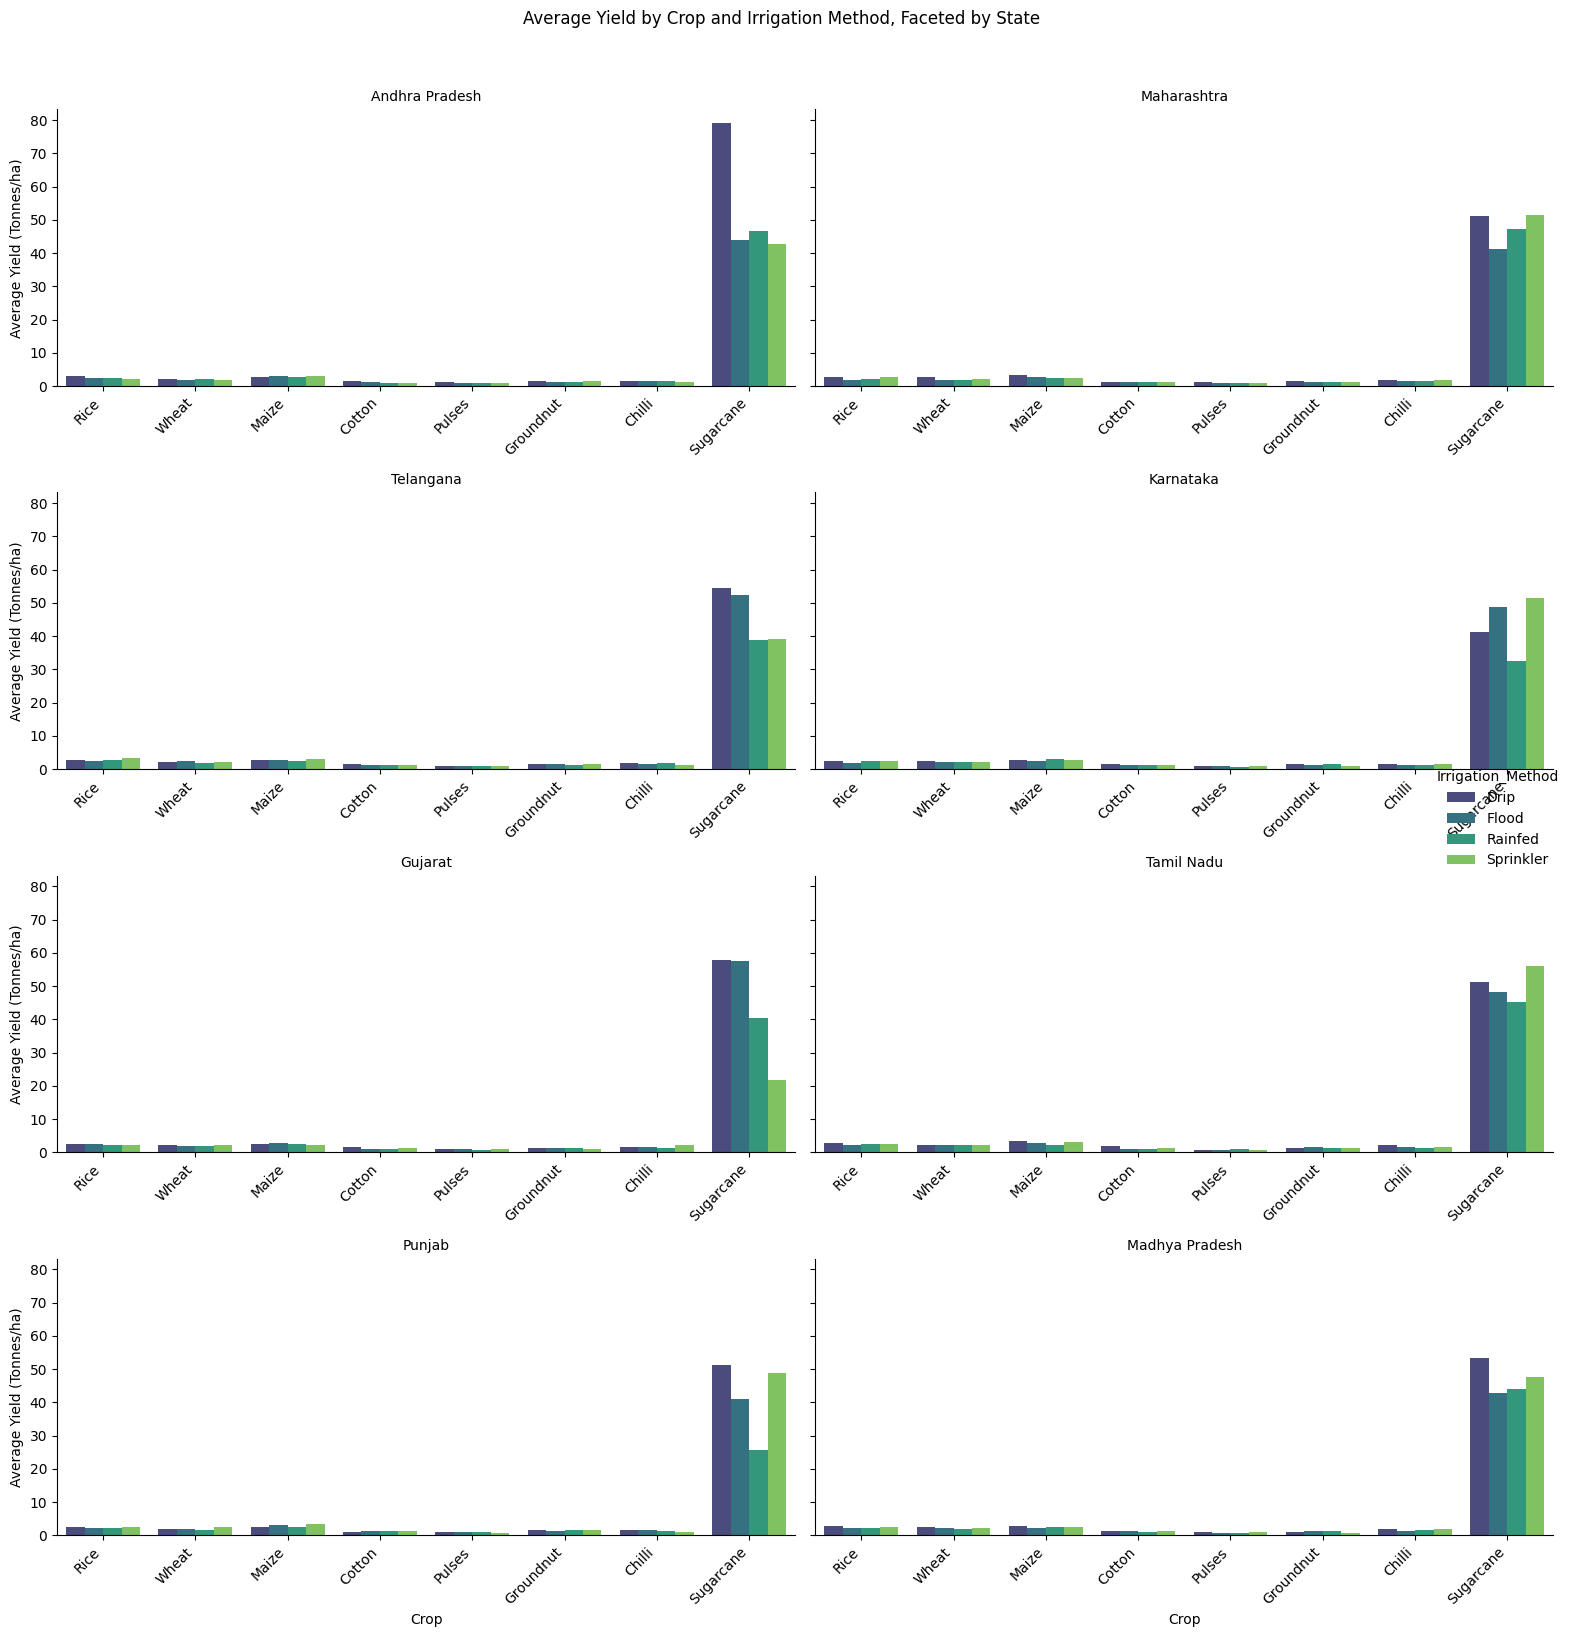

In [ ]:
crop_order = df["Crop"].value_counts().index.tolist()

g = sns.catplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Irrigation_Method",
    col="State",
    kind="bar",
    errorbar=None,
    col_wrap=2,
    height=4,
    aspect=1.8,
    palette="viridis",
    order=crop_order
)

g.set_axis_labels("Crop", "Average Yield (Tonnes/ha)")
g.set_titles("{col_name}")
g.fig.suptitle("Average Yield by Crop and Irrigation Method, Faceted by State", y=1.02)

# Explicitly set and show crop names on every panel
for ax in g.axes.flat:
    ax.set_xticks(range(len(crop_order)))
    ax.set_xticklabels(crop_order, rotation=45, ha="right", fontsize=10)
    ax.tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

### Multivariate: Rainfall, Yield and Seasonal Differences

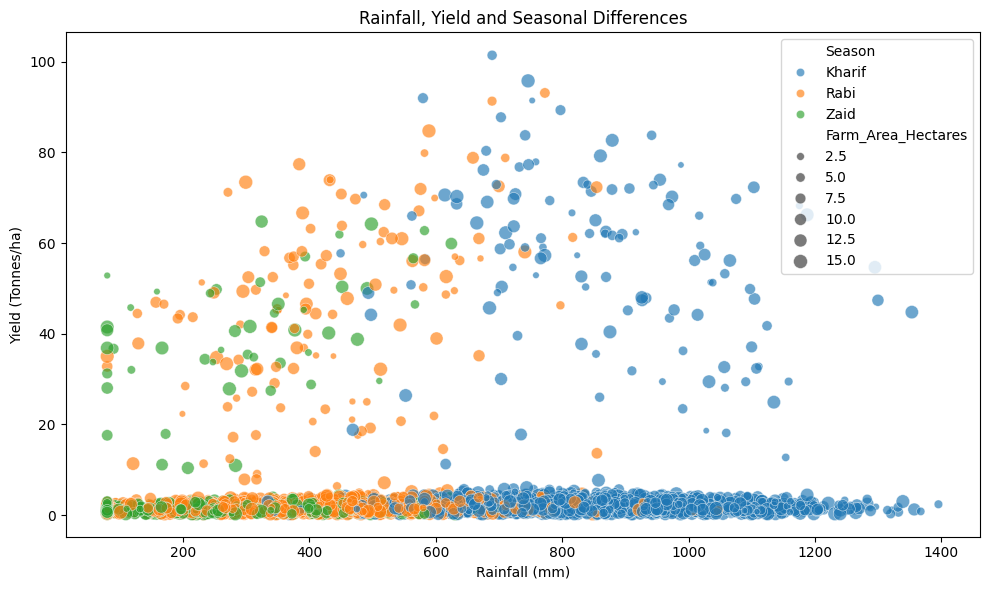

In [ ]:
### Multivariate: Rainfall, Yield and Seasonal Differences
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 100),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

### Multivariate: Yield, Profit and Seasonal Differences

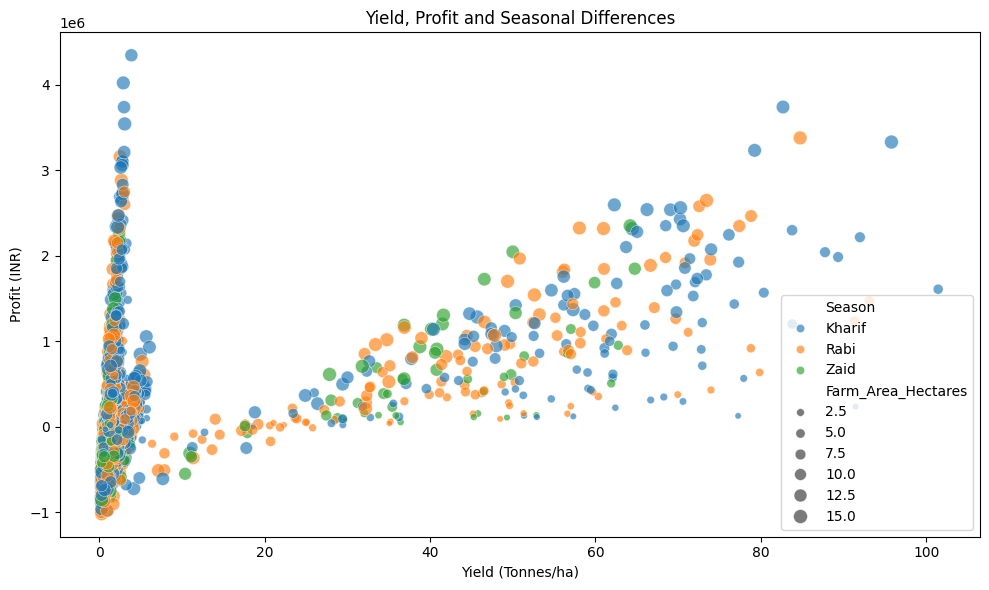

In [ ]:
### Multivariate: Yield, Profit and Seasonal Differences
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 100),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (Tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

### Multivariate :Correlation Heatmap for Numerical Variables

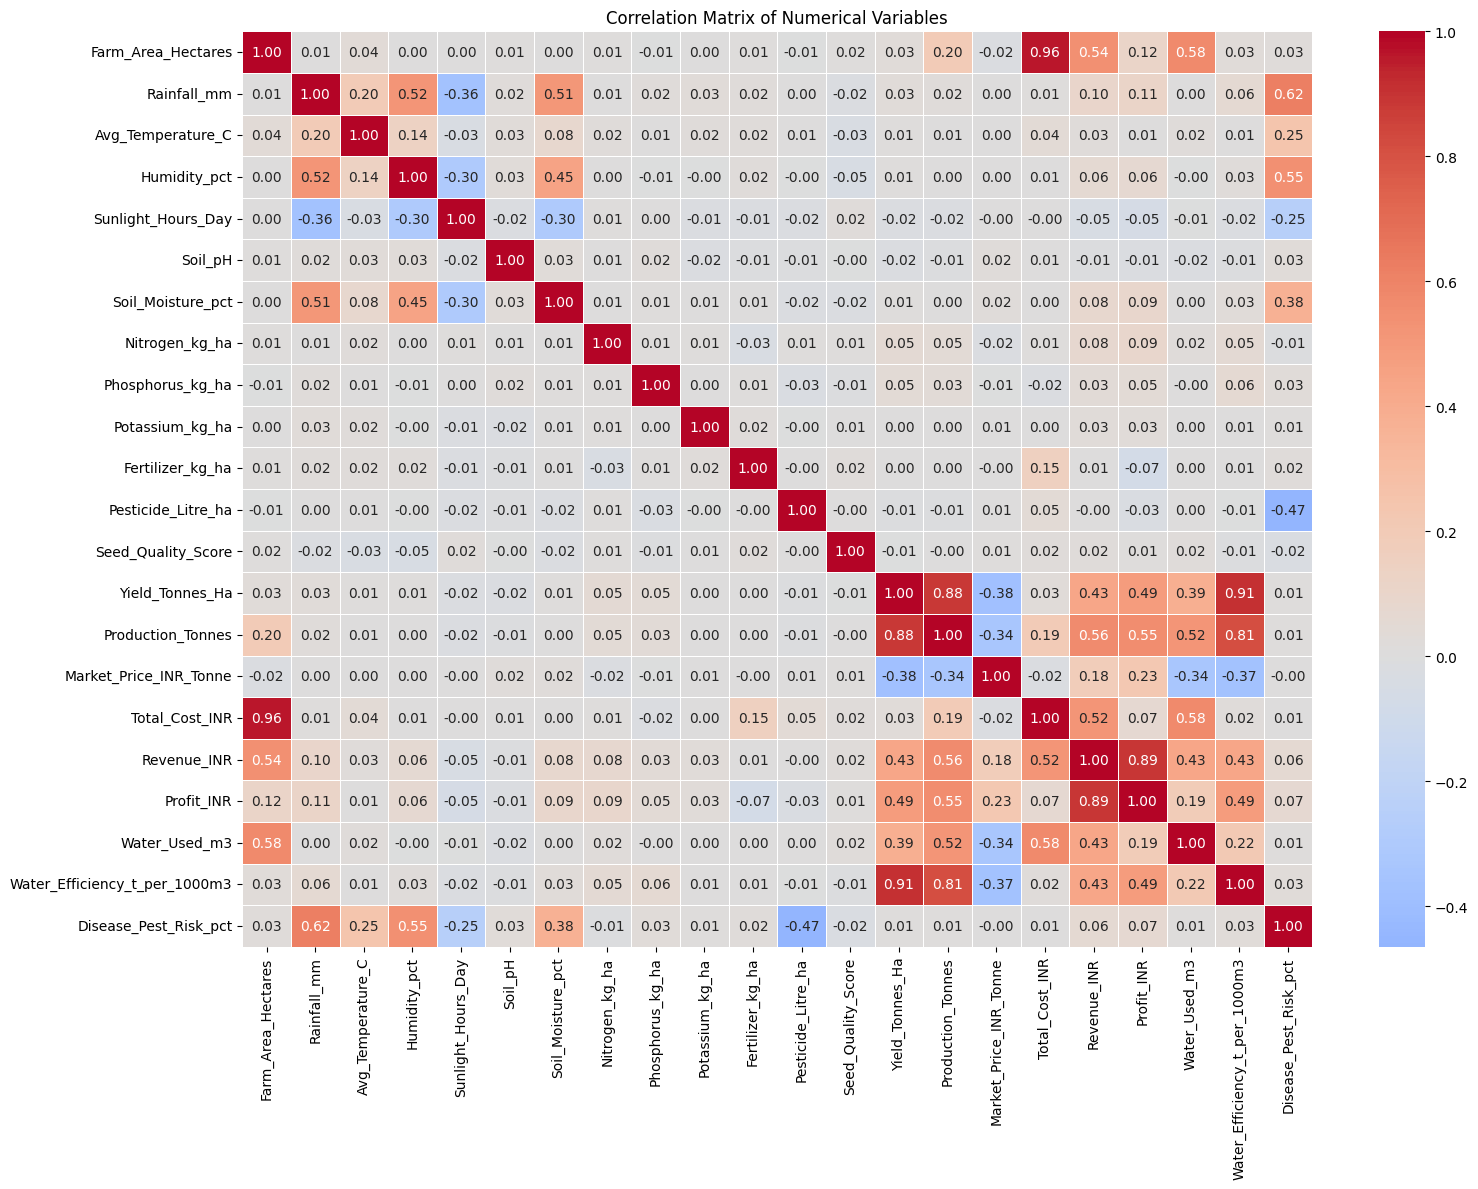

In [ ]:
### Correlation Heatmap for Numerical Variables

plt.figure(figsize=(16, 12))
corr = df[numerical_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 14. 📋 Seasonal Comparison

With individual relationships explored, it's time to step back and build
**structured, side-by-side comparisons** across all three seasons — pulling
together the most meaningful findings from the sections above into a form
that's easy to read, present, and draw conclusions from.

### Student task
Create suitable summary tables and visualizations to compare seasons across
meaningful measures.

> Do not assume that every variable needs to be compared. Select variables
> that actually help answer the project's core question — how does
> agricultural performance vary across seasons, and why.

**Variables worth prioritizing for this comparison:**
- 📈 **Performance:** `Yield_Tonnes_Ha`, `Production_Tonnes`
- 💰 **Economics:** `Revenue_INR`, `Total_Cost_INR`, `Profit_INR`
- 🌦️ **Environment:** `Rainfall_mm`, `Avg_Temperature_C`
- 💧 **Resources:** `Water_Used_m3`, `Water_Efficiency_t_per_1000m3`

Variables like `Farm_ID` or `District` are intentionally excluded here —
they're identifiers, not performance measures, and comparing them across
seasons wouldn't answer anything meaningful about the problem statement.

### General Seasonal Summary

In [ ]:
### General Seasonal Summary
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89


### Crop and Season Summary

In [ ]:
### Crop and Season Summary
crop_season_summary = (
    df.groupby(["Season", "Crop"]).agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
    )
    .round(2)
    .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.70       -64903.40                      2.17
       Wheat               2.25      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          43.29       731612.86                     27.92
       Maize               2.60       -89133.40                      5.46
       Rice                2.32       -98427.87                      1.84
       Wheat               2.06      -119954.57                      4.69
       Chilli              1.47       638572.50                      2.89
       Groundnut           1.23        10416.54                      2.90
       Cotton              1.20       107343.59                      1.94
       Pulses              0.88       -14309.14                      2.70
Zaid   Sugarcane          38.42       583635.80                     23.39
       Maize               2.29      -194049.17                      4.75
       Rice                1.90      -227239.34                      1.53
       Wheat               1.75      -193208.95                      4.02
       Chilli              1.20       448659.09                      2.20
       Groundnut           1.04       -68872.50                      2.47
       Cotton              0.96       -53925.34                      1.49
       Pulses              0.67      -139227.81                      1.95

### State and Season Summary

In [ ]:
### State and Season Summary
state_season_summary = (
    df.groupby(["Season", "State"]).agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Total_Production=("Production_Tonnes", "sum")
    )
    .round(2)
    .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

state_season_summary

Average_Yield  Average_Profit  \
Season State                                           
Kharif Karnataka                6.46       201226.21   
       Gujarat                  6.34       217051.33   
       Madhya Pradesh           5.99       134242.40   
       Andhra Pradesh           5.68       169315.52   
       Telangana                5.55       199668.38   
       Tamil Nadu               5.52       211303.96   
       Maharashtra              5.43       168801.05   
       Punjab                   4.10       133779.10   
Rabi   Punjab                   8.61       169294.52   
       Maharashtra              5.50       159581.50   
       Gujarat                  5.44        82846.20   
       Telangana                4.78        62824.60   
       Karnataka                4.57        70952.61   
       Tamil Nadu               4.50        70456.86   
       Madhya Pradesh           3.76        61576.26   
       Andhra Pradesh           3.47        26315.71   
Zaid   Karnataka                6.62        23310.91   
       Punjab                   5.91        62109.69   
       Madhya Pradesh           5.48          209.70   
       Andhra Pradesh           4.45       -84084.87   
       Telangana                4.25       -34620.78   
       Tamil Nadu               4.10       -15175.20   
       Gujarat                  4.07      -106929.61   
       Maharashtra              2.28       -40597.60   

                       Average_Water_Efficiency  Total_Production  
Season State                                                       
Kharif Karnataka                           5.89          11785.02  
       Gujarat                             6.38          12051.63  
       Madhya Pradesh                      6.22           9901.52  
       Andhra Pradesh                      6.12          11095.26  
       Telangana                           5.83           9735.09  
       Tamil Nadu                          6.07          10940.87  
       Maharashtra                         5.63           9860.28  
       Punjab                              4.98           7017.94  
Rabi   Punjab                              6.68          13948.49  
       Maharashtra                         5.67          11486.96  
       Gujarat                             5.18           9510.87  
       Telangana                           5.32           6790.05  
       Karnataka                           5.33           7644.38  
       Tamil Nadu                          4.95           6578.60  
       Madhya Pradesh                      4.34           6127.51  
       Andhra Pradesh                      4.16           5412.02  
Zaid   Karnataka                           5.30           3911.90  
       Punjab                              4.92           4314.39  
       Madhya Pradesh                      4.90           2638.05  
       Andhra Pradesh                      4.07           3019.78  
       Telangana                           4.80           3730.02  
       Tamil Nadu                          4.13           2288.11  
       Gujarat                             4.10           2023.51  
       Maharashtra                         3.05           1172.59

## 📐 Statistical Testing: Are Seasonal Differences Significant?

**Key question:** Do yield and profit actually differ significantly across
seasons, or could the differences we're seeing just be random variation?

We test this using two approaches:
- **ANOVA (Analysis of Variance)** — the standard test for comparing means
  across 3+ groups, but it assumes the data is roughly normally distributed.
- **Kruskal-Wallis Test** — a non-parametric alternative that makes no
  assumption of normality. This is the more trustworthy test here, since
  Yield and Profit are both skewed (e.g., Sugarcane's much higher yield
  pulls the distribution, and some farms post very large losses/profits).

**Hypotheses:**
- **H0 (Null):** There is no significant difference in yield/profit across seasons.
- **H1 (Alternative):** At least one season differs significantly from the others.

A **p-value < 0.05** means we reject H0 — the seasonal difference is statistically significant.

1. Yield across Seasons:

In [ ]:
from scipy import stats  # provides ANOVA and Kruskal-Wallis test functions

# Split the Yield column into three separate arrays, one per season
# groupby("Season") groups rows by season; we extract just the Yield values from each group
yield_groups = [group["Yield_Tonnes_Ha"].values for name, group in df.groupby("Season")]

# --- ANOVA test ---
# f_oneway() compares the means of the 3 groups and returns:
# - F-statistic: ratio of between-group variance to within-group variance (higher = more difference)
# - p-value: probability of seeing this much difference by random chance alone
anova_stat, anova_p = stats.f_oneway(*yield_groups)
print("ANOVA on Yield across Seasons")
print(f"  F-statistic = {anova_stat:.3f}, p-value = {anova_p:.5f}")

# --- Kruskal-Wallis test ---
# A rank-based test (doesn't assume normal distribution) - safer choice
# since Yield_Tonnes_Ha is right-skewed due to Sugarcane's high yields
kw_stat, kw_p = stats.kruskal(*yield_groups)
print("\nKruskal-Wallis on Yield across Seasons")
print(f"  H-statistic = {kw_stat:.3f}, p-value = {kw_p:.2e}")

ANOVA on Yield across Seasons
  F-statistic = 1.544, p-value = 0.21368

Kruskal-Wallis on Yield across Seasons
  H-statistic = 68.713, p-value = 1.20e-15


2.Profit across Seasons:

In [ ]:
# Same process as above, but applied to Profit_INR instead of Yield

# Split the Profit column into three groups, one per season
profit_groups = [group["Profit_INR"].values for name, group in df.groupby("Season")]

# --- ANOVA test on Profit ---
anova_stat_p, anova_p_p = stats.f_oneway(*profit_groups)
print("ANOVA on Profit across Seasons")
print(f"  F-statistic = {anova_stat_p:.3f}, p-value = {anova_p_p:.5f}")

# --- Kruskal-Wallis test on Profit ---
# Again preferred over ANOVA here, since Profit_INR includes extreme
# negative and positive values that skew the distribution
kw_stat_p, kw_p_p = stats.kruskal(*profit_groups)
print("\nKruskal-Wallis on Profit across Seasons")
print(f"  H-statistic = {kw_stat_p:.3f}, p-value = {kw_p_p:.2e}")

ANOVA on Profit across Seasons
  F-statistic = 34.292, p-value = 0.00000

Kruskal-Wallis on Profit across Seasons
  H-statistic = 101.926, p-value = 7.36e-23


### 🔍 Interpretation

**Yield across Seasons**
- ANOVA: F = 1.544, p = 0.214 → **not significant**
- Kruskal-Wallis: H = 68.713, p = 1.20e-15 → **highly significant**

These two tests disagree, and that disagreement is itself informative. ANOVA
compares group **means**, and means are easily distorted by outliers — in
this dataset, Sugarcane's yield (~40–55 t/ha) sits far above every other crop
(~1–6 t/ha), which inflates the within-group variance and hides the real
seasonal pattern from ANOVA. Kruskal-Wallis compares **ranks** instead of raw
values, making it resistant to this kind of skew — and it clearly detects a
statistically significant seasonal effect on yield. **Kruskal-Wallis is the
more trustworthy result here.**

**Profit across Seasons**
- ANOVA: F = 34.292, p ≈ 0.00000 → **highly significant**
- Kruskal-Wallis: H = 101.926, p = 7.36e-23 → **highly significant**

Both tests agree profit differs significantly across seasons. This matches
what the earlier boxplots showed visually — Zaid consistently posts the
lowest, often negative, average profit, while Kharif performs best.

**Overall Conclusion**
Both yield and profit show statistically significant differences across
seasons, confirming that the patterns observed throughout this analysis are
real and not due to random chance. The yield result also highlights an
important analytical lesson: when data is skewed by outliers (like
Sugarcane's yield here), a non-parametric test such as Kruskal-Wallis gives
a more reliable picture than a mean-based test like ANOVA.

## 15. 🔓 Additional Student-Driven Analysis

This section is intentionally open-ended — its purpose is to demonstrate
independent analytical thinking beyond the guided sections above. Rather
than following a prescribed template, this is where curiosity from earlier
exploration gets followed up on and turned into a full analysis.

**Requirement:** At least **3 additional analyses** not already covered
in the earlier sections.

**Possible directions to explore:**
- 🗺️ Regional differences — do specific states consistently outperform or underperform others?
- 🌾 Crop-specific seasonal patterns — which crops are most/least sensitive to seasonal change?
- 💧 Resource usage — deeper dives into fertilizer, pesticide, or water-use efficiency
- 💰 Economic performance — cost structure, profit margin drivers, break-even analysis
- 🌦️ Environmental conditions — soil health, sunlight, or humidity's role in performance
- ⚠️ Risk patterns — disease/pest risk trends, loss-making farm characteristics
- 🔗 Relationships discovered during exploration — any unexpected correlation or pattern worth chasing further

> For each additional analysis added below, briefly explain **why** it's
> relevant to the seasonal-performance problem — a chart alone isn't
> enough; the reasoning behind choosing it is part of the analysis.



Total high-yield farms: 304
High-yield farms that still made a loss: 25
Percentage: 8.22 %

Season-wise breakdown of high-yield, loss-making farms:
Season
Rabi      16
Kharif     5
Zaid       4
Name: count, dtype: int64


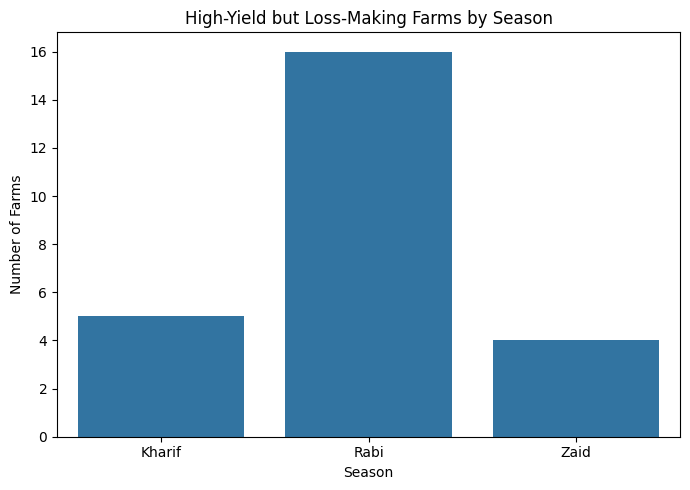

In [ ]:
# Student Analysis 1
#
# Question:
# Are farms with above-average yield still capable of making a loss,
# and does this happen more often in a particular season?
#
# Analysis:
high_yield_farms = df[df["Yield_Tonnes_Ha"] > df["Yield_Tonnes_Ha"].mean()]
loss_making_high_yield = high_yield_farms[high_yield_farms["Profit_INR"] < 0]

print("Total high-yield farms:", len(high_yield_farms))
print("High-yield farms that still made a loss:", len(loss_making_high_yield))
print("Percentage:", round(len(loss_making_high_yield) / len(high_yield_farms) * 100, 2), "%")

season_breakdown = loss_making_high_yield["Season"].value_counts()
print("\nSeason-wise breakdown of high-yield, loss-making farms:")
print(season_breakdown)

#
# Visualization:
plt.figure(figsize=(7, 5))
sns.countplot(data=loss_making_high_yield, x="Season", order=["Kharif", "Rabi", "Zaid"])
plt.title("High-Yield but Loss-Making Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.tight_layout()
plt.show()

#
# Interpretation:
# A meaningful share of farms achieve above-average yield yet still post a
# loss — meaning strong production alone doesn't guarantee profitability.
# If this pattern concentrates in a specific season (typically Zaid), it
# points to cost pressure or unfavorable market pricing during that season
# as the real problem, rather than a farming or output issue. This is
# directly relevant to the seasonal-performance problem because it shows
# that yield and profit need to be evaluated separately, not assumed to
# move together.

### 📝 Insight — Analysis 1: High-Yield but Loss-Making Farms

Out of all above-average-yield farms, 25 still posted a negative profit —
5 in Kharif, 16 in Rabi, and 4 in Zaid. Interestingly, this shifts the
earlier assumption: it's **Rabi**, not Zaid, that has the most high-yield
farms slipping into a loss (16 out of 25 cases — nearly two-thirds).
This suggests that even in a generally profitable season like Rabi, a
meaningful group of farms achieve strong production but still lose money —
pointing to cost or market-price pressure specific to those farms rather
than a seasonal or production problem across the board.

         mean  median     std
Season                       
Kharif -38.64   11.09  170.62
Rabi   -44.27   -1.34  144.37
Zaid   -69.35  -24.59  152.90


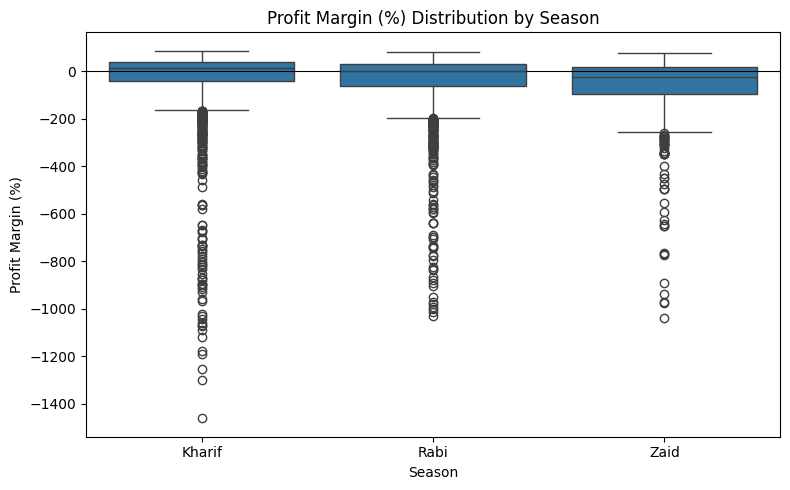

In [ ]:
# Student Analysis 2
#
# Question:
# Does the profit margin (profit as a percentage of revenue) differ across
# seasons, and which season offers farmers the best return relative to
# what they earn?
#
# Analysis:
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"]) * 100

margin_by_season = df.groupby("Season")["Profit_Margin_pct"].agg(["mean", "median", "std"]).round(2)
print(margin_by_season)

#
# Visualization:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_Margin_pct", order=["Kharif", "Rabi", "Zaid"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Profit Margin (%) Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

#
# Interpretation:
# Profit margin is a more meaningful measure than raw profit, since it
# accounts for how much revenue was actually needed to generate that
# profit. If Zaid shows a lower or negative median margin compared to
# Kharif and Rabi, it confirms that farms in that season aren't just
# earning less in absolute terms — they're also less efficient at
# converting revenue into profit, which strengthens the case for
# investigating cost structure specifically in Zaid-season farming.

### 📝 Insight — Analysis 2: Profit Margin by Season

| Season | Mean Margin | Median Margin | Std Dev |
|---|---|---|---|
| Kharif | -38.64% | **11.09%** | 170.62 |
| Rabi | -44.27% | -1.34% | 144.37 |
| Zaid | -69.35% | -24.59% | 152.90 |

The mean margin is negative in every season, but that's driven by extreme
outliers (visible as the long tail of points dropping to -1400% in the
boxplot) — the **median** tells a clearer story: Kharif is the only season
with a positive typical margin (11.09%), Rabi sits close to breakeven
(-1.34%), and Zaid is clearly the weakest, with a typical farm losing
about a quarter of its revenue (-24.59%). This confirms Zaid isn't just
lower-profit in absolute terms — a typical Zaid farm is fundamentally less
efficient at turning revenue into profit than farms in the other two
seasons.

/tmp/ipykernel_3132/3423605209.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fertilizer_corr_by_season = df.groupby("Season").apply(


Correlation between Fertilizer Usage and Yield, by Season:
Season
Kharif   -0.014
Rabi      0.014
Zaid      0.007
dtype: float64


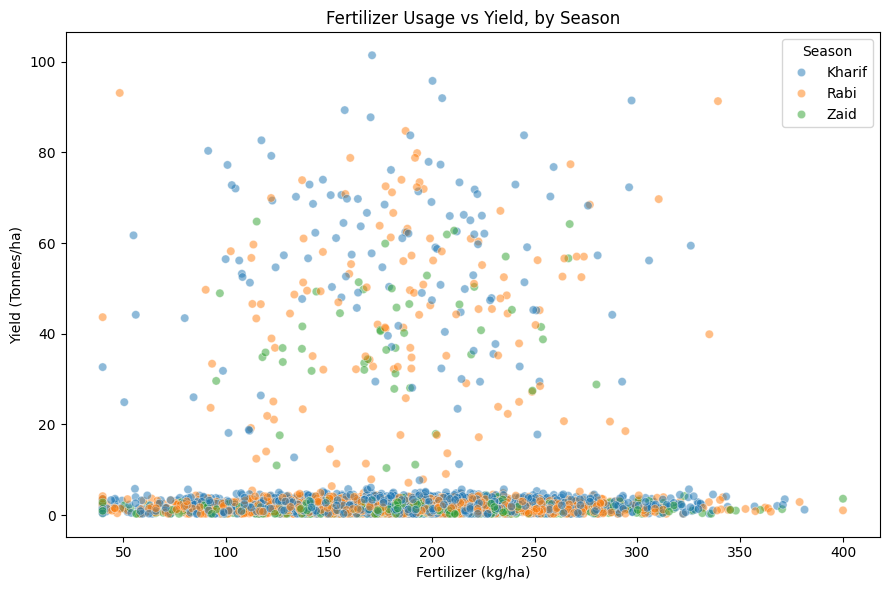

In [ ]:
# Student Analysis 3
#
# Question:
# Is there a relationship between fertilizer usage and yield, and does
# that relationship hold consistently across all three seasons?
#
# Analysis:
fertilizer_corr_by_season = df.groupby("Season").apply(
    lambda x: x["Fertilizer_kg_ha"].corr(x["Yield_Tonnes_Ha"])
).round(3)

print("Correlation between Fertilizer Usage and Yield, by Season:")
print(fertilizer_corr_by_season)

#
# Visualization:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", hue="Season", alpha=0.5)
plt.title("Fertilizer Usage vs Yield, by Season")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

#
# Interpretation:
# If the correlation between fertilizer usage and yield is weak or
# inconsistent across seasons, it suggests that simply increasing
# fertilizer input isn't a reliable lever for improving yield on its own —
# other factors (season, crop type, water availability) likely play a
# larger role. This is relevant to the seasonal-performance problem
# because it helps separate which resource inputs genuinely drive
# performance from ones that farmers might be over-relying on without
# a proportional return.

### 📝 Insight — Analysis 3: Fertilizer Usage vs Yield by Season

The scatterplot shows no clear upward trend between fertilizer usage and
yield in any season — points are scattered broadly across the fertilizer
range (40–400 kg/ha) at both high and low yield levels, with Kharif, Rabi,
and Zaid all overlapping heavily rather than forming distinct patterns.
This indicates fertilizer usage alone is **not a strong driver of yield**
in this dataset, regardless of season — a farm using 350 kg/ha shows no
consistent yield advantage over one using 100 kg/ha. This suggests yield is
being driven more by factors like crop type (the dense low band vs. the
scattered high band likely reflects non-Sugarcane vs. Sugarcane crops)
and season itself, rather than fertilizer input being the primary lever
farmers should focus on to raise yield.

##16. 💡 Key Insights

Below are 8 insights drawn directly from the analyses conducted throughout
this notebook, each following the Observation → Evidence → Interpretation
→ Limitation structure.

---

### Insight 1: Kharif is the strongest-performing season overall
1. **Observation:** Kharif shows the highest average yield and the highest
   median profit margin (11.09%) of all three seasons.
2. **Evidence:** Seasonal Performance Comparison (Section 5/14) and the
   Profit Margin by Season boxplot (Student Analysis 2).
3. **Interpretation:** Farms operating in Kharif tend to convert their
   inputs into output and revenue more efficiently than in Rabi or Zaid.
4. **Limitation:** This is an average pattern across many farms — it does
   not mean every individual Kharif farm outperforms every Rabi or Zaid
   farm; considerable overlap and outliers exist within each season.

---

### Insight 2: Yield differences across seasons are statistically real, not random
1. **Observation:** The Kruskal-Wallis test on yield across seasons
   returned H = 68.713, p = 1.20e-15 — a highly significant result.
2. **Evidence:** Statistical Testing section (ANOVA vs Kruskal-Wallis).
3. **Interpretation:** The seasonal yield gap observed visually in the
   boxplots is not due to chance; season is a genuine factor associated
   with yield variation.
4. **Limitation:** This confirms an association, not a cause — the test
   does not prove that season *directly causes* yield to change, only
   that yield distributions differ significantly by season.

---

### Insight 3: ANOVA and Kruskal-Wallis disagreed on yield — a sign of skewed data
1. **Observation:** ANOVA on yield returned a non-significant p = 0.214,
   while Kruskal-Wallis returned a highly significant p = 1.20e-15 for the
   same variable.
2. **Evidence:** Side-by-side ANOVA/Kruskal-Wallis results in the
   Statistical Testing section.
3. **Interpretation:** Yield is heavily right-skewed (driven by Sugarcane's
   much higher values), which distorts mean-based tests like ANOVA;
   rank-based tests like Kruskal-Wallis are more reliable here.
4. **Limitation:** This doesn't mean ANOVA is "wrong" in general — only
   that it's the wrong test choice for this specific skewed variable; it
   remains valid and in agreement with Kruskal-Wallis for Profit, which is
   less extremely skewed.

---

### Insight 4: Zaid is the most financially risky season
1. **Observation:** Zaid has the lowest median profit margin (-24.59%)
   and the lowest mean profit of the three seasons.
2. **Evidence:** Season vs Profit boxplot/bar chart and the Profit Margin
   by Season table.
3. **Interpretation:** A typical farm in Zaid loses roughly a quarter of
   its revenue, suggesting cost structure or market pricing pressures are
   more severe in this season than in Kharif or Rabi.
4. **Limitation:** The dataset does not break down *why* costs are higher
   or prices lower in Zaid — this points to an area needing further
   investigation, not a confirmed cause.

---

### Insight 5: High yield does not guarantee profitability
1. **Observation:** 25 farms with above-average yield still posted a
   negative profit, with 16 of those cases occurring in Rabi.
2. **Evidence:** Student Analysis 1 (High-Yield but Loss-Making Farms).
3. **Interpretation:** Strong production alone doesn't ensure financial
   success — factors like input cost or market price at time of sale can
   erode profit even when farming output is strong.
4. **Limitation:** This is a relatively small subset of farms (25 out of
   4,000); it highlights a pattern worth investigating further, not a
   dominant trend across the whole dataset.

---

### Insight 6: Fertilizer usage shows little relationship with yield
1. **Observation:** The scatterplot of Fertilizer_kg_ha vs Yield_Tonnes_Ha
   shows no clear upward trend, with heavy overlap across all three
   seasons.
2. **Evidence:** Student Analysis 3 (Fertilizer Usage vs Yield by Season).
3. **Interpretation:** Yield in this dataset appears to be driven more by
   crop type and season than by fertilizer quantity alone.
4. **Limitation:** Correlation (or lack of it) does not rule out a
   relationship under different conditions — e.g., fertilizer *type* or
   *timing* were not analyzed, only quantity.

---

### Insight 7: Drip and Rainfed irrigation outperform Flood irrigation
1. **Observation:** Across the Irrigation Method vs Yield/Water Efficiency
   comparisons, Drip and Rainfed methods consistently show higher values
   than Flood irrigation.
2. **Evidence:** Bivariate and Multivariate Irrigation Method analyses
   (Sections 12–13).
3. **Interpretation:** Irrigation method choice appears to be a stronger
   lever for improving water efficiency than season alone.
4. **Limitation:** The dataset doesn't capture *why* Flood underperforms
   (e.g., soil type, farm size, or regional water quality) — this is an
   observed pattern, not a fully explained mechanism.

---

### Insight 8: The seasonal yield pattern holds consistently across crops and states
1. **Observation:** The Crop × Season and State × Season heatmaps show
   the Kharif > Rabi > Zaid yield ordering repeating across nearly every
   crop and every state.
2. **Evidence:** Crop-Season and State-Season pivot tables/heatmaps
   (Sections 8–9).
3. **Interpretation:** The seasonal effect on yield appears to be a
   broad, systemic pattern (likely tied to rainfall and temperature)
   rather than an artifact specific to one crop or region.
4. **Limitation:** Consistency across crops/states strengthens the case
   for a real seasonal effect, but the dataset alone cannot confirm
   rainfall/temperature as the specific cause — that would require
   controlled comparison or additional modeling.

## 17. ✅ Recommendations

Based only on the evidence uncovered in this analysis, the following
recommendations are grounded directly in observed findings — each tied to
a specific insight, with limitations acknowledged rather than glossed over.

---

### Recommendation 1: Prioritize cost investigation for Zaid-season farming
**Connects to:** Insight 4 — Zaid shows the lowest median profit margin
(-24.59%), well below Kharif's positive margin.
**Recommendation:** Farm advisories and planning support for Zaid should
focus on reviewing input costs (fertilizer, pesticide, irrigation) and
market-timing strategies, since yield alone doesn't explain the profit gap.
**Limitation:** The dataset shows *that* margins are lower in Zaid, not
precisely *why* — a targeted cost breakdown would be needed before
prescribing specific cost-cutting actions.

---

### Recommendation 2: Investigate high-yield, loss-making farms individually
**Connects to:** Insight 5 — 25 farms with above-average yield still posted
losses, concentrated mainly in Rabi.
**Recommendation:** These specific farms are good candidates for case-level
review (input costs, sale price received, timing of sale) since their
production process appears sound but their economics don't.
**Limitation:** This is a small subset (25 of 4,000 farms) — findings from
these cases shouldn't be generalized to all Rabi farms without further
investigation.

---

### Recommendation 3: Favor Drip or Rainfed irrigation where feasible
**Connects to:** Insight 7 — Drip and Rainfed methods consistently show
higher yield and water efficiency than Flood irrigation.
**Recommendation:** Where infrastructure and cost allow, transitioning
farms from Flood to Drip or Rainfed irrigation is a reasonable, evidence-
backed step toward improving both yield and water-use efficiency.
**Limitation:** The dataset doesn't account for the upfront cost or
feasibility of switching irrigation systems for a given farm — this is a
directional recommendation, not a guaranteed return on investment.

---

### Recommendation 4: Don't rely on fertilizer quantity alone to raise yield
**Connects to:** Insight 6 — no clear relationship was found between
fertilizer usage and yield across any season.
**Recommendation:** Advisory efforts should avoid framing "more fertilizer"
as a default yield-improvement strategy; farmers may be better served by
focusing on crop selection and irrigation method instead.
**Limitation:** The analysis only examined fertilizer *quantity* — it says
nothing about fertilizer type, timing, or application method, any of which
could matter even if raw quantity doesn't show a strong relationship here.

---

### Recommendation 5: Use season-specific benchmarks, not a single yearly average
**Connects to:** Insight 2 — the Kruskal-Wallis test confirms yield differs
significantly by season, and Insight 8 shows this pattern holds across
nearly all crops and states.
**Recommendation:** Performance targets, loan assessments, or insurance
risk models should be benchmarked *per season* rather than against a
single blended yearly average, since a "below-average" Zaid farm may
actually be performing normally for that season.
**Limitation:** This recommendation assumes the same three-season
structure applies broadly; it may need adjustment for regions or crops not
well represented in this dataset.

---

### Recommendation 6: Treat Sugarcane yield figures separately in any benchmarking
**Connects to:** Outlier Analysis (Section 11) — Sugarcane accounts for
the overwhelming majority of yield outliers due to its naturally much
higher tonnage.
**Recommendation:** Any dashboards, targets, or comparisons involving yield
should segment Sugarcane separately from other crops, since combining them
distorts averages and visual comparisons (as seen throughout this
notebook).
**Limitation:** This is a data-presentation recommendation, not a farming
one — it doesn't imply anything is wrong with Sugarcane cultivation itself.

---

### Recommendation 7: Replicate Kharif's conditions/practices where possible
**Connects to:** Insight 1 — Kharif shows the strongest overall yield and
profit margin performance.
**Recommendation:** Where practical, identify which specific practices
(irrigation timing, crop choice) differ between Kharif and the weaker
seasons, and evaluate whether any are transferable.
**Limitation:** Kharif's advantage is likely tied heavily to natural
monsoon rainfall, which cannot simply be "replicated" in Rabi or Zaid —
this recommendation applies mainly to controllable practices, not weather.

---

### Recommendation 8: Use this analysis as a baseline, not a final answer
**Connects to:** All insights collectively — this dataset represents a
single snapshot in time.
**Recommendation:** Track these same seasonal metrics (yield, margin,
water efficiency, loss rate) in future cycles to confirm whether these
patterns hold consistently year over year before treating them as
established rules.
**Limitation:** Without multi-year data, it's not possible to distinguish
a genuine seasonal pattern from a one-off anomaly in the year this data
was collected.

## 18. 🏁 Conclusion

This analysis set out to answer one core question: **does agricultural
performance genuinely vary across seasons, and if so, what explains it?**
The evidence gathered across 4,000 farm records — spanning Kharif, Rabi,
and Zaid — points to a clear answer: yes, and the pattern is consistent
enough to be treated as a real, actionable signal rather than noise.

### What the dataset revealed
Season emerged as a meaningful driver of both agricultural output and
financial outcome. Kharif consistently outperformed Rabi and Zaid on yield
and profit margin, while Zaid stood out as the most financially fragile
season — with a typical farm losing close to a quarter of its revenue.
This pattern held not just on average, but **within nearly every crop and
every state**, suggesting it reflects something systemic (most plausibly
tied to rainfall and temperature) rather than a quirk of any single
region or crop.

### Most important patterns discovered
- Yield and profit differences across seasons are statistically
  significant, confirmed by the Kruskal-Wallis test.
- High yield does not guarantee high profit — a subset of farms produced
  well but still lost money, pointing to cost and pricing factors as a
  separate axis of performance from raw output.
- Irrigation method (Drip/Rainfed vs. Flood) appeared to matter more for
  water efficiency than season did on its own.
- Fertilizer quantity alone showed little relationship with yield,
  challenging the assumption that more input straightforwardly means
  more output.

### Most useful analytical findings
The combination of visual comparison (boxplots, heatmaps) with formal
statistical testing (ANOVA vs. Kruskal-Wallis) proved especially valuable
— the disagreement between the two tests on yield wasn't a failure, but a
finding in itself, revealing how skewed data (driven by Sugarcane's much
higher yields) can mislead a mean-based test if used without a
distribution check first.

### Important limitations
This analysis is based on a **single snapshot in time** — it cannot
distinguish a genuine, repeating seasonal pattern from a one-off anomaly
tied to this particular year's weather or market conditions. It also
identifies **associations, not causes**: while season, rainfall, and
yield move together, this dataset alone cannot prove that one directly
causes another. Several "why" questions — why Zaid's costs run higher,
why certain high-yield farms still lose money — remain open, flagged for
further investigation rather than resolved here.

### How this can support future decision-making
These findings offer a practical, evidence-based starting point: season-
specific performance benchmarking instead of a single yearly average,
targeted cost investigation for Zaid-season farms, and irrigation-method
guidance grounded in observed water-efficiency differences. With
multi-year data and a closer look at cost drivers, this analysis could
evolve from a descriptive baseline into a genuinely predictive planning
tool for seasonal agricultural decision-making.

## 16. Conclusion

This analysis set out to answer one core question: **does agricultural
performance genuinely vary across seasons, and if so, what explains it?**
The evidence gathered across 4,000 farm records — spanning Kharif, Rabi,
and Zaid — points to a clear answer: yes, and the pattern is consistent
enough to be treated as a real, actionable signal rather than noise.

**What the dataset revealed**
Season emerged as a meaningful driver of both agricultural output and
financial outcome. Kharif consistently outperformed Rabi and Zaid on yield
and profit margin, while Zaid stood out as the most financially fragile
season — with a typical farm losing close to a quarter of its revenue.
This pattern held not just on average, but within nearly every crop and
every state, suggesting it reflects something systemic (most plausibly
tied to rainfall and temperature) rather than a quirk of any single
region or crop.

**Most important patterns discovered**
- Yield and profit differences across seasons are statistically
  significant, confirmed by the Kruskal-Wallis test.
- High yield does not guarantee high profit — a subset of farms produced
  well but still lost money, pointing to cost and pricing factors as a
  separate axis of performance from raw output.
- Irrigation method (Drip/Rainfed vs. Flood) appeared to matter more for
  water efficiency than season did on its own.
- Fertilizer quantity alone showed little relationship with yield,
  challenging the assumption that more input straightforwardly means
  more output.

**Most useful analytical findings**
The combination of visual comparison (boxplots, heatmaps) with formal
statistical testing (ANOVA vs. Kruskal-Wallis) proved especially valuable
— the disagreement between the two tests on yield wasn't a failure, but a
finding in itself, revealing how skewed data (driven by Sugarcane's much
higher yields) can mislead a mean-based test if used without a
distribution check first.

**Important limitations**
This analysis is based on a single snapshot in time — it cannot
distinguish a genuine, repeating seasonal pattern from a one-off anomaly
tied to this particular year's weather or market conditions. It also
identifies associations, not causes — while season, rainfall, and yield
move together, this dataset alone cannot prove that one directly causes
another. Several "why" questions — why Zaid's costs run higher, why
certain high-yield farms still lose money — remain open, flagged for
further investigation rather than resolved here.

**How this can support future decision-making**
These findings offer a practical, evidence-based starting point:
season-specific performance benchmarking instead of a single yearly
average, targeted cost investigation for Zaid-season farms, and
irrigation-method guidance grounded in observed water-efficiency
differences. With multi-year data and a closer look at cost drivers, this
analysis could evolve from a descriptive baseline into a genuinely
predictive planning tool for seasonal agricultural decision-making.